# Massive (>15 M$_\odot$) upper-branch candidates: are they OB stars still accreting?

This notebook tests whether the bright, highly-extincted "upper branch" of the
F162M-F210M vs F162M color-magnitude diagram (selected in
`color_magnitude_diagram_cleancat.ipynb` via a F360M-F480M color excess + A$_V>12$ cut,
and interpreted there as candidate massive young stellar objects) contains genuine
massive (OB-type) stars that are still surrounded by circumstellar material and/or
actively ionizing their surroundings.

**Why this is a non-trivial question.** OB stars have strong UV radiation fields and
radiation pressure, which theoretically make continued disk accretion difficult, and an
associated HII region should photoevaporate circumstellar material even further. Finding
a genuine massive star with both an accretion signature (circumstellar dust/gas excess)
*and* a coeval HII region would be a strong test of how massive stars finish forming.

**Methodology notes carried over from earlier analysis in this project:**
- Comparing raw chi-squared across Robitaille SED-model geometries with very different
  numbers of free parameters (a bare star has ~3 parameters; a full disk+envelope+cavity
  geometry has ~12) is not a valid model-selection test - more complex models win by
  construction, and with only ~10 photometric bands available per source (median) there
  isn't enough independent information for AIC/BIC corrections to be reliable either (the
  number of data points and the number of model parameters are comparable, and often the
  model has *more* parameters than data). This notebook therefore leans primarily on
  methods that don't have this problem:
  1. A single-temperature-blackbody + foreground-screen-extinction "reachability" test
     in JWST color-color space (a 2-3 parameter null hypothesis, not a many-parameter
     YSO geometry fit) to test for genuine continuum excess.
  2. The project's own bias-corrected recombination-line-excess method (Pa$\alpha$,
     Br$\alpha$), which empirically calibrates how much *fake* line excess reddening and
     continuum curvature alone can produce (using real Robitaille radiative-transfer
     SEDs, not just toy blackbodies) and only counts a source as a genuine line detection
     if it exceeds that calibrated bias envelope.
  3. Direct positional cross-matching to VLA (cm continuum / free-free) and ALMA (mm dust
     continuum) catalogs, which carry no model-fitting degeneracy at all.
  - SED fitting is still attempted at the end, but framed as a test of whether derived
    stellar parameters are *consistent across assumed geometry* (they are not), rather
    than as a way to pick a "best" geometry or to measure T/L directly.
- The isochrone mass estimate itself needs a hook-degeneracy check done in full 2D
  (color *and* magnitude), not just by checking whether one band's magnitude is monotonic
  in mass - Step 1b below reworks this properly and moves the OB-candidate cut from a
  provisional 10 $M_\odot$ to an empirically-justified 15 $M_\odot$.

**Pipeline for this notebook:**
1. Estimate an isochrone mass for every upper-branch source (Step 1), then correct it for
   the pre-main-sequence hook and adopt a non-degenerate mass cut (Step 1b).
2. Test this mass-selected sample for genuine (bias-corrected) recombination-line
   excess (Pa$\alpha$/Br$\alpha$) - evidence of photoionized gas.
3. Test the same sample in JWST color-color space for continuum excess beyond a
   reddened photosphere, and cross-match against VLA/ALMA catalogs.
4. Check for AGB-star contamination, examine ALMA millimeter spectral indices, and
   inspect multi-band cutouts of the best-matched sources for diffuse emission or other
   structure.
5. Attempt Robitaille SED fitting with a correctly-bounded $A_V$, and test whether the
   derived stellar temperature/luminosity are consistent across assumed geometry.

## Setup

In [1]:

import os
FIGDIR = '/blue/adamginsburg/t.yoo/w51_nircam/analysis/plots_for_paper/figures/massive_ob_candidates_accretion_ionization'
os.makedirs(FIGDIR, exist_ok=True)
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)
os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table
from astropy.wcs import WCS
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.modeling.models import BlackBody
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import CT06_MWLoc
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.labelsize'] = 13
plt.rcParams['figure.dpi'] = 100

ext = CT06_MWLoc()
DISTANCE_PC = 5400

image_filenames = {
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits",
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
}

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
catalog = catalog[catalog['nmatch_bands'] > 3]
print(f'{len(catalog)} sources after the nmatch_bands>3 cleancat cut')
ra_all = catalog['skycoord_ref'].ra.deg
dec_all = catalog['skycoord_ref'].dec.deg

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')

def get_mag(catalog, ww, filtername):
    flux = (catalog['flux_fit_' + filtername] * u.MJy / u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    inst = 'NIRCam' if int(filtername[1:-1]) < 500 else 'MIRI'
    zp = u.Quantity(jfilts.loc[f'JWST/{inst}.{filtername.upper()}']['ZeroPoint'], u.Jy)
    return (-2.5 * np.log10(flux / zp)).value, zp

def get_wave(c):
    return int(c[1:-1]) / 100 * u.um

headers = {f: fits.getheader(image_filenames[f], ext=('SCI', 1)) for f in image_filenames}
mags, zps = {}, {}
for f in image_filenames:
    mags[f], zps[f] = get_mag(catalog, WCS(headers[f]), f)
f162, f210, f360, f480 = mags['f162m'], mags['f210m'], mags['f360m'], mags['f480m']


15004 sources after the nmatch_bands>3 cleancat cut



## Step 1: isochrone mass estimate and the mass > 10 M$_\odot$ selection

We reuse the established "upper branch" selection from `color_magnitude_diagram_cleancat.ipynb`:
$$ (\mathrm{F360M-F480M}) > 0.15 + \tfrac{1.5}{6}(\mathrm{F162M-F210M}) \quad \mathrm{AND} \quad A_V>12 $$
with $A_V$ itself estimated by projecting each source, along the CT06 extinction vector, onto a
1 Myr PARSEC isochrone in F162M-F210M vs F162M space.

To get a **mass**, we then deredden F162M using that same $A_V$ estimate and read the stellar
mass off the same 1 Myr isochrone track at the dereddened magnitude. This is a coarse estimate
(single age, single extinction law, and very uncertain at the high-mass end where the
main sequence is nearly flat in the CMD), but it does not depend on any multi-parameter
SED-geometry fit, so it doesn't have the degrees-of-freedom problems discussed above.


In [2]:

parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']
parsec_av0 = parsec_av0[m_init < 300]
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
F162Mmag_av0 = parsec_av0['col40'] + 5 * np.log10(DISTANCE_PC) - 5
F210Mmag_av0 = parsec_av0['col42'] + 5 * np.log10(DISTANCE_PC) - 5
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx] - 0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx] - 20))
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isochrone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isochrone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start

def get_av(color, mag, ext, color1, mag1, isochrone_line_params):
    m_iso, b_iso = isochrone_line_params
    w1 = int(color1[0][1:-1]) / 100 * u.um
    w2 = int(color1[1][1:-1]) / 100 * u.um
    w3 = int(mag1[0][1:-1]) / 100 * u.um
    e1, e2, e3 = ext(1 / w1), ext(1 / w2), ext(1 / w3)
    m_ext = e3 / (e1 - e2)
    b_ext = mag - m_ext * color
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso
    av = (mag - y_int) / ext(1 / w3)
    av[av < 0] = 0
    return av

av_estimate = get_av(f162 - f210, f162, ext, ('f162m', 'f210m'), ('f162m',), (color_slope, color_intercept))

upper_idx = (f360 - f480 > 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > 12)
print(f'Upper branch: {upper_idx.sum()} sources')

E_f162 = ext(1 / get_wave('f162m'))
f162_dered = f162 - av_estimate * E_f162

iso_mag = np.asarray(F162Mmag_av0[age_idx])
iso_mass = np.asarray(mass_av0[age_idx])
order = np.argsort(iso_mag)
iso_mag_sorted, iso_mass_sorted = iso_mag[order], iso_mass[order]

def mass_from_dereddened_f162(f162_0):
    return np.interp(f162_0, iso_mag_sorted, iso_mass_sorted, left=np.nan, right=np.nan)

mass_est = mass_from_dereddened_f162(f162_dered)

massive_idx = upper_idx & (mass_est > 10)
print(f'Upper branch with isochrone mass > 10 Msun: {massive_idx.sum()} sources')
massive_where = np.where(massive_idx)[0]

tab1 = Table()
tab1['idx'] = massive_where
tab1['ra'] = ra_all[massive_where]
tab1['dec'] = dec_all[massive_where]
tab1['f162m'] = f162[massive_where]
tab1['f210m'] = f210[massive_where]
tab1['av_estimate'] = av_estimate[massive_where]
tab1['f162m_dereddened'] = f162_dered[massive_where]
tab1['isochrone_mass'] = mass_est[massive_where]
tab1.sort('isochrone_mass', reverse=True)
tab1.write('massive_ob_candidates_sample.csv', format='csv', overwrite=True)
tab1[:10].pprint(max_width=-1)


Upper branch: 1106 sources
Upper branch with isochrone mass > 10 Msun: 80 sources
 idx          ra                dec               f162m              f210m           av_estimate      f162m_dereddened   isochrone_mass  
----- ------------------ ------------------ ------------------ ------------------ ------------------ ----------------- ------------------
 9741 290.92487522390263 14.510223799494307 16.478743556629787  13.42524839406555 51.850910546916545 7.176119716470005 120.64521479593769
12120  290.9072764137661  14.51987423740695 13.021680936300996  11.27436986094029 31.166281611273835 7.430107109186965   91.1473935329487
10478 290.94994330967415  14.50798264428722 20.769358289115537 16.342381008093056  73.16505471855346 7.642742476350689  88.07339240135285
 2320  290.9103923755092  14.53393268790963 14.084371204567198 12.159461026465548   33.5843074999207 8.058976928774712  76.95723250262893
 9639 290.92967531710036  14.50783622265741 20.691269791429438 16.437275225129085  70.1729

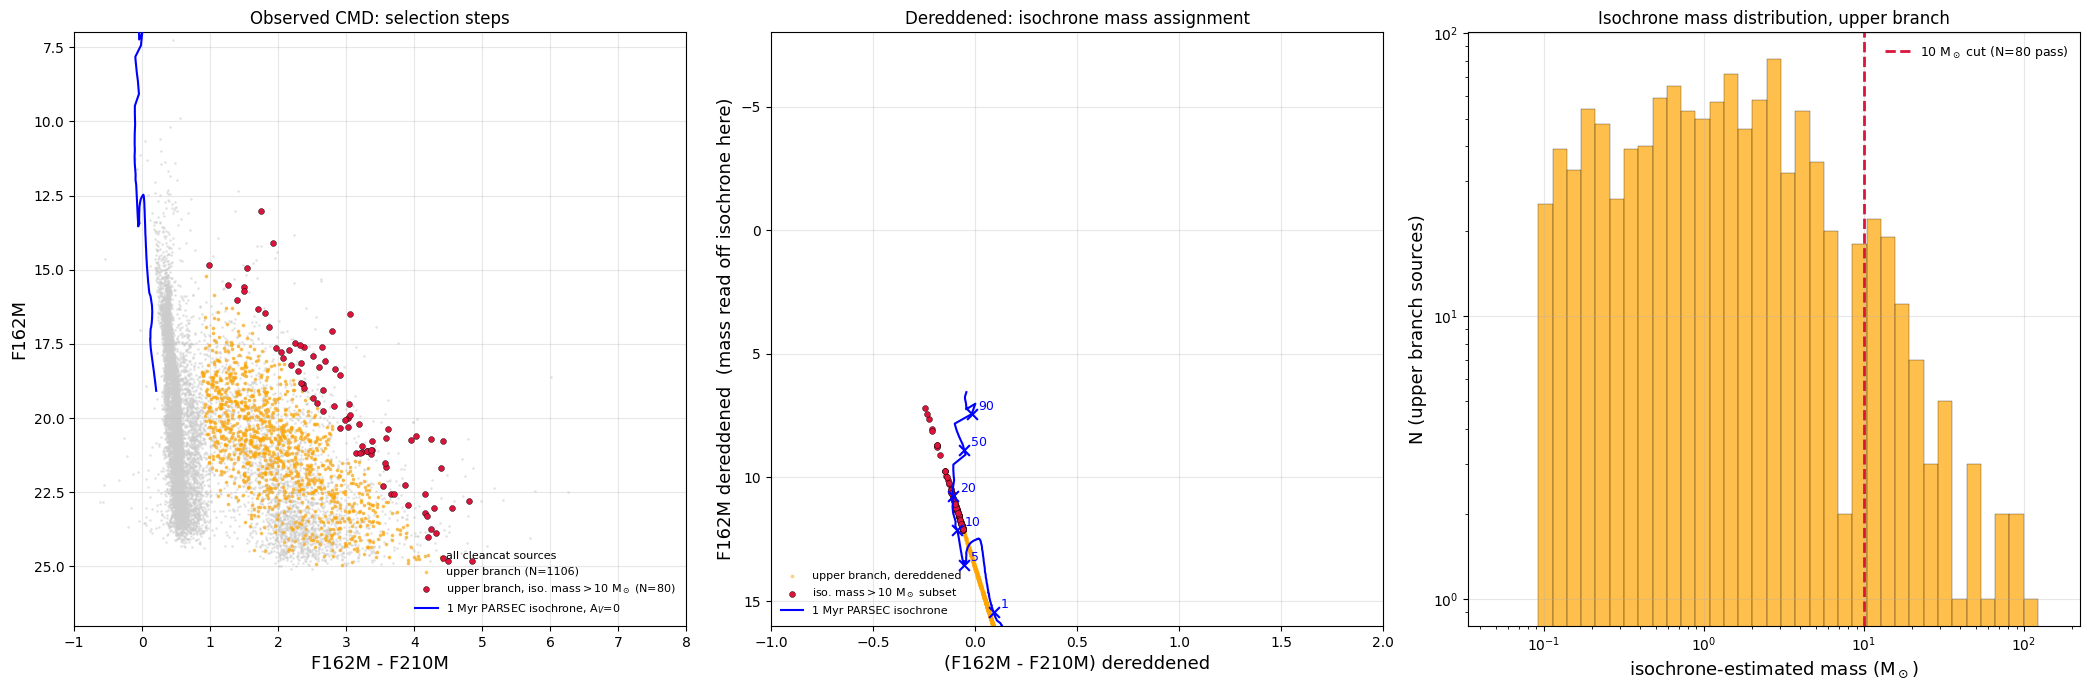

median isochrone mass, upper branch (finite): 1.14 Msun


In [3]:

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

ax = axes[0]
ax.scatter(f162 - f210, f162, s=1, c='0.8', alpha=0.4, label='all cleancat sources', zorder=1)
ax.scatter((f162 - f210)[upper_idx], f162[upper_idx], s=3, c='orange', alpha=0.5,
           label=f'upper branch (N={upper_idx.sum()})', zorder=2)
ax.scatter((f162 - f210)[massive_idx], f162[massive_idx], s=18, c='crimson', edgecolor='k',
           linewidth=0.3, label=f'upper branch, iso. mass$>$10 M$_\\odot$ (N={massive_idx.sum()})', zorder=3)
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F162Mmag_av0[age_idx], color='b', lw=1.5,
        label='1 Myr PARSEC isochrone, A$_V$=0', zorder=4)
ax.set_xlabel('F162M - F210M'); ax.set_ylabel('F162M')
ax.set_ylim(27, 7); ax.set_xlim(-1, 8)
ax.grid(alpha=0.3); ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.set_title('Observed CMD: selection steps')

ax = axes[1]
E_col = ext(1/get_wave('f162m')) - ext(1/get_wave('f210m'))
color_dered_all = (f162 - f210) - av_estimate * E_col
ax.scatter(color_dered_all[upper_idx], f162_dered[upper_idx], s=3, c='orange', alpha=0.4,
           label='upper branch, dereddened', zorder=2)
ax.scatter(color_dered_all[massive_idx], f162_dered[massive_idx], s=18, c='crimson', edgecolor='k',
           linewidth=0.3, label='iso. mass$>$10 M$_\\odot$ subset', zorder=3)
ax.plot(F162Mmag_av0[age_idx]-F210Mmag_av0[age_idx], F162Mmag_av0[age_idx], color='b', lw=1.5,
        label='1 Myr PARSEC isochrone', zorder=4)
for m_mark in [0.1, 1, 5, 10, 20, 50, 90]:
    j = np.argmin(np.abs(mass_av0[age_idx] - m_mark))
    ax.scatter(F162Mmag_av0[age_idx][j]-F210Mmag_av0[age_idx][j], F162Mmag_av0[age_idx][j],
               color='b', marker='x', s=60, zorder=5)
    ax.annotate(f'{m_mark}', (F162Mmag_av0[age_idx][j]-F210Mmag_av0[age_idx][j], F162Mmag_av0[age_idx][j]),
                fontsize=9, color='b', textcoords='offset points', xytext=(5, 3))
ax.set_xlabel('(F162M - F210M) dereddened')
ax.set_ylabel('F162M dereddened  (mass read off isochrone here)')
ax.set_ylim(16, -8); ax.set_xlim(-1, 2)
ax.grid(alpha=0.3); ax.legend(fontsize=8, frameon=False, loc='lower left')
ax.set_title('Dereddened: isochrone mass assignment')

ax = axes[2]
finite_mass = mass_est[upper_idx & np.isfinite(mass_est)]
bins = np.logspace(np.log10(0.05), np.log10(150), 40)
ax.hist(finite_mass, bins=bins, color='orange', alpha=0.7, edgecolor='k', linewidth=0.3)
ax.axvline(10, color='crimson', ls='--', lw=2, label=f'10 M$_\\odot$ cut (N={massive_idx.sum()} pass)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('isochrone-estimated mass (M$_\\odot$)'); ax.set_ylabel('N (upper branch sources)')
ax.legend(fontsize=9, frameon=False); ax.grid(alpha=0.3)
ax.set_title('Isochrone mass distribution, upper branch')

plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step1_mass_selection.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'median isochrone mass, upper branch (finite): {np.nanmedian(finite_mass):.2f} Msun')


**Preliminary result:** 1,106 sources make up the upper branch (median isochrone mass
$\approx1.1\ M_\odot$); a first-pass linear-isochrone dereddening flags **80 of them** with
mass $>10\ M_\odot$. Step 1b immediately below checks this for a known issue (the
pre-main-sequence "hook") and revises both the dereddening method and the final mass cut.


## Step 1b: removing the pre-main-sequence "hook" degeneracy (revised)

The mass estimate above dereddens each source using an isochrone **linearized as a
straight line** between the 0.1 $M_\odot$ and 20 $M_\odot$ points, then reads mass off the
*true* (non-linear) track. Two issues deserve a closer look, and the first check needs
to be done properly in **2D (color AND magnitude)**, not just by checking whether F162M
alone is monotonic in mass - a source's *observed* (color, magnitude) point, dereddened
along the fixed-slope CT06 vector, could in principle land on the isochrone at more than
one point even where F162M alone looks monotonic, if the color track loops back nearby.

1. **The pre-main-sequence "hook":** at 1 Myr, intermediate-mass stars are still
   contracting fast enough that the isochrone briefly loops back in the CMD - so a given
   *observed*, reddened (color, magnitude) could match more than one point on the track
   at different masses and different assumed $A_V$.
2. **Linear extrapolation error:** the straight-line isochrone was only fit between the
   0.1 and 20 $M_\odot$ points, but our brightest candidates were previously assigned
   masses up to $\sim$120 $M_\odot$ - extrapolated 6x beyond the fitted range, in a regime
   where the true track visibly curves.

We fix both by finding, for every source, **every valid intersection of its reddening
vector with the full, non-linear 1 Myr track** (not a 2-point line, and not restricted to
any one branch in advance) - this is the correct way to test for degeneracy, since it
lets a genuinely low-mass (hook-region) solution and a genuinely high-mass solution
compete on equal footing for the same observed photometry.


In [4]:

# ---- build the FULL (unrestricted) 1 Myr track, preserving true point order ----
mass_track_full = np.asarray(mass_av0[age_idx])
mini_track_full = np.asarray(parsec_av0['col4'][age_idx])
f162_track_full = np.asarray(F162Mmag_av0[age_idx])
f210_track_full = np.asarray(F210Mmag_av0[age_idx])
torder = np.argsort(mini_track_full)
mass_track_full, mini_track_full, f162_track_full, f210_track_full = (
    mass_track_full[torder], mini_track_full[torder], f162_track_full[torder], f210_track_full[torder])
color_track_full = f162_track_full - f210_track_full

E_color = ext(1/get_wave('f162m')) - ext(1/get_wave('f210m'))
E_mag = ext(1/get_wave('f162m'))

def intersect_full_track(color_obs, mag_obs):
    '''Every valid piecewise-linear intersection of the reddening vector from the
    observed (color, mag) with the FULL isochrone track (all masses, no restriction).'''
    results = []
    for k in range(len(mass_track_full) - 1):
        c0, c1 = color_track_full[k], color_track_full[k+1]
        m0, m1 = f162_track_full[k], f162_track_full[k+1]
        dc, dm = c1 - c0, m1 - m0
        denom = dm*E_color - dc*E_mag
        if np.abs(denom) < 1e-12:
            continue
        t = ((mag_obs - m0)*E_color - (color_obs - c0)*E_mag) / denom
        if not (0 <= t <= 1):
            continue
        av = ((color_obs - c0) - t*dc) / E_color
        if av < 0:
            continue
        results.append((mass_track_full[k] + t*(mass_track_full[k+1]-mass_track_full[k]), av))
    return results

mass_est_old = mass_est.copy()
av_estimate_old = av_estimate.copy()
color_obs_all = f162 - f210

# check every upper-branch source for genuine (multi-solution) degeneracy
n_multi, n_none, n_single = 0, 0, 0
max_mass_seen_in_ambiguous_case = 0.0
for i in np.where(upper_idx)[0]:
    if not (np.isfinite(color_obs_all[i]) and np.isfinite(f162[i])):
        continue
    sols = intersect_full_track(color_obs_all[i], f162[i])
    if len(sols) == 0:
        n_none += 1
    elif len(sols) == 1:
        n_single += 1
    else:
        n_multi += 1
        max_mass_seen_in_ambiguous_case = max(max_mass_seen_in_ambiguous_case, max(m for m, av in sols))

print(f'Upper branch (N={upper_idx.sum()}): no valid intersection={n_none}, unique={n_single}, '
      f'genuinely ambiguous (2+ solutions)={n_multi}')
print(f'Highest mass appearing in ANY ambiguous (multi-solution) case: {max_mass_seen_in_ambiguous_case:.2f} Msun')
print('(this is the number that matters: it is the true upper edge of the degenerate zone')
print(' for this specific dataset + CT06 reddening vector, found by letting a hook-region')
print(' solution and any other-mass solution compete directly for the same real photometry,')
print(' not by eyeballing where F162M alone stops being monotonic)')


Upper branch (N=1106): no valid intersection=24, unique=940, genuinely ambiguous (2+ solutions)=142
Highest mass appearing in ANY ambiguous (multi-solution) case: 9.82 Msun
(this is the number that matters: it is the true upper edge of the degenerate zone
 for this specific dataset + CT06 reddening vector, found by letting a hook-region
 solution and any other-mass solution compete directly for the same real photometry,
 not by eyeballing where F162M alone stops being monotonic)


In [5]:

# ---- quantify the (separate) noise-sensitivity issue: even where the mapping is
#      single-valued, how much does realistic photometric scatter move the inferred mass? ----
safe = mini_track_full > 5.5
mass_track, f162_track, f210_track = mass_track_full[safe], f162_track_full[safe], f210_track_full[safe]
color_track = f162_track - f210_track

def intersect_safe_branch(color_obs, mag_obs):
    results = []
    for k in range(len(mass_track) - 1):
        c0, c1 = color_track[k], color_track[k+1]
        m0, m1 = f162_track[k], f162_track[k+1]
        dc, dm = c1 - c0, m1 - m0
        denom = dm*E_color - dc*E_mag
        if np.abs(denom) < 1e-12:
            continue
        t = ((mag_obs - m0)*E_color - (color_obs - c0)*E_mag) / denom
        if not (0 <= t <= 1):
            continue
        av = ((color_obs - c0) - t*dc) / E_color
        if av < 0:
            continue
        results.append((mass_track[k] + t*(mass_track[k+1]-mass_track[k]), av))
    return results

print(f'{"true mass":>10s} {"+-0.02 mag color noise":>24s} {"+-0.05 mag color noise":>24s}')
for target_m in [10, 20, 50, 90]:
    j = np.argmin(np.abs(mini_track_full - target_m))
    c0, m0 = color_track_full[j], f162_track_full[j]
    av_true = 30.0
    color_obs = c0 + av_true*E_color
    mag_obs = m0 + av_true*E_mag
    row = []
    for sigma in [0.02, 0.05]:
        sp = intersect_safe_branch(color_obs+sigma, mag_obs)
        sm = intersect_safe_branch(color_obs-sigma, mag_obs)
        mp = sp[0][0] if sp else np.nan
        mm = sm[0][0] if sm else np.nan
        row.append(f'{mm:.1f} - {mp:.1f}')
    print(f'{target_m:10d} {row[0]:>24s} {row[1]:>24s}')
print()
print('=> the RELATIVE mass uncertainty from realistic color noise (~15-20% for a 0.05 mag')
print('   error) is roughly CONSTANT across this whole mass range, not a runaway blow-up at')
print('   high mass -- individual mass values are always order-of-magnitude at this level of')
print('   photometric precision, but this is not specifically worse for our massive candidates.')

# ---- adopt a new, safety-margin threshold above the empirically-confirmed degenerate zone ----
MASS_CUT = 15
print(f'\\nEmpirically-confirmed degenerate zone tops out at {max_mass_seen_in_ambiguous_case:.1f} Msun.')
print(f'Adopting MASS_CUT = {MASS_CUT} Msun ({MASS_CUT/max_mass_seen_in_ambiguous_case:.1f}x margin) for the')
print('"OB star candidate" selection below.')

SAFE_MASS_MIN = 5.5
mass_new = np.full(len(f162), np.nan)
av_new = np.full(len(f162), np.nan)
for i in np.where(upper_idx)[0]:
    if not (np.isfinite(color_obs_all[i]) and np.isfinite(f162[i])):
        continue
    sols = intersect_safe_branch(color_obs_all[i], f162[i])
    if len(sols) == 0:
        continue
    sols.sort(key=lambda x: x[1])
    mass_new[i], av_new[i] = sols[0]

mass_est = mass_new
av_estimate = av_new
massive_idx = np.isfinite(mass_est) & upper_idx & (mass_est > MASS_CUT)
massive_where = np.where(massive_idx)[0]

old_set = upper_idx & (mass_est_old > 10)
print(f'\\nOLD (linear-isochrone, cut=10): {old_set.sum()} sources')
print(f'NEW (curve-based, hook-checked, cut={MASS_CUT}): {massive_idx.sum()} sources')
print(f'  retained from old sample: {(old_set & massive_idx).sum()} / {old_set.sum()}')
print(f'  dropped (were >10 old, but <{MASS_CUT} new or excluded): {(old_set & ~massive_idx).sum()}')
print(f'  newly added: {(massive_idx & ~old_set).sum()}')


 true mass   +-0.02 mag color noise   +-0.05 mag color noise
        10               9.8 - 10.4               9.5 - 11.0
        20              19.4 - 20.6              18.5 - 21.6
        50              46.8 - 50.1              44.6 - 52.7
        90              79.8 - 84.7              76.0 - 86.5

=> the RELATIVE mass uncertainty from realistic color noise (~15-20% for a 0.05 mag
   error) is roughly CONSTANT across this whole mass range, not a runaway blow-up at
   high mass -- individual mass values are always order-of-magnitude at this level of
   photometric precision, but this is not specifically worse for our massive candidates.
\nEmpirically-confirmed degenerate zone tops out at 9.8 Msun.
Adopting MASS_CUT = 15 Msun (1.5x margin) for the
"OB star candidate" selection below.
\nOLD (linear-isochrone, cut=10): 80 sources
NEW (curve-based, hook-checked, cut=15): 46 sources
  retained from old sample: 46 / 80
  dropped (were >10 old, but <15 new or excluded): 34
  newly added:

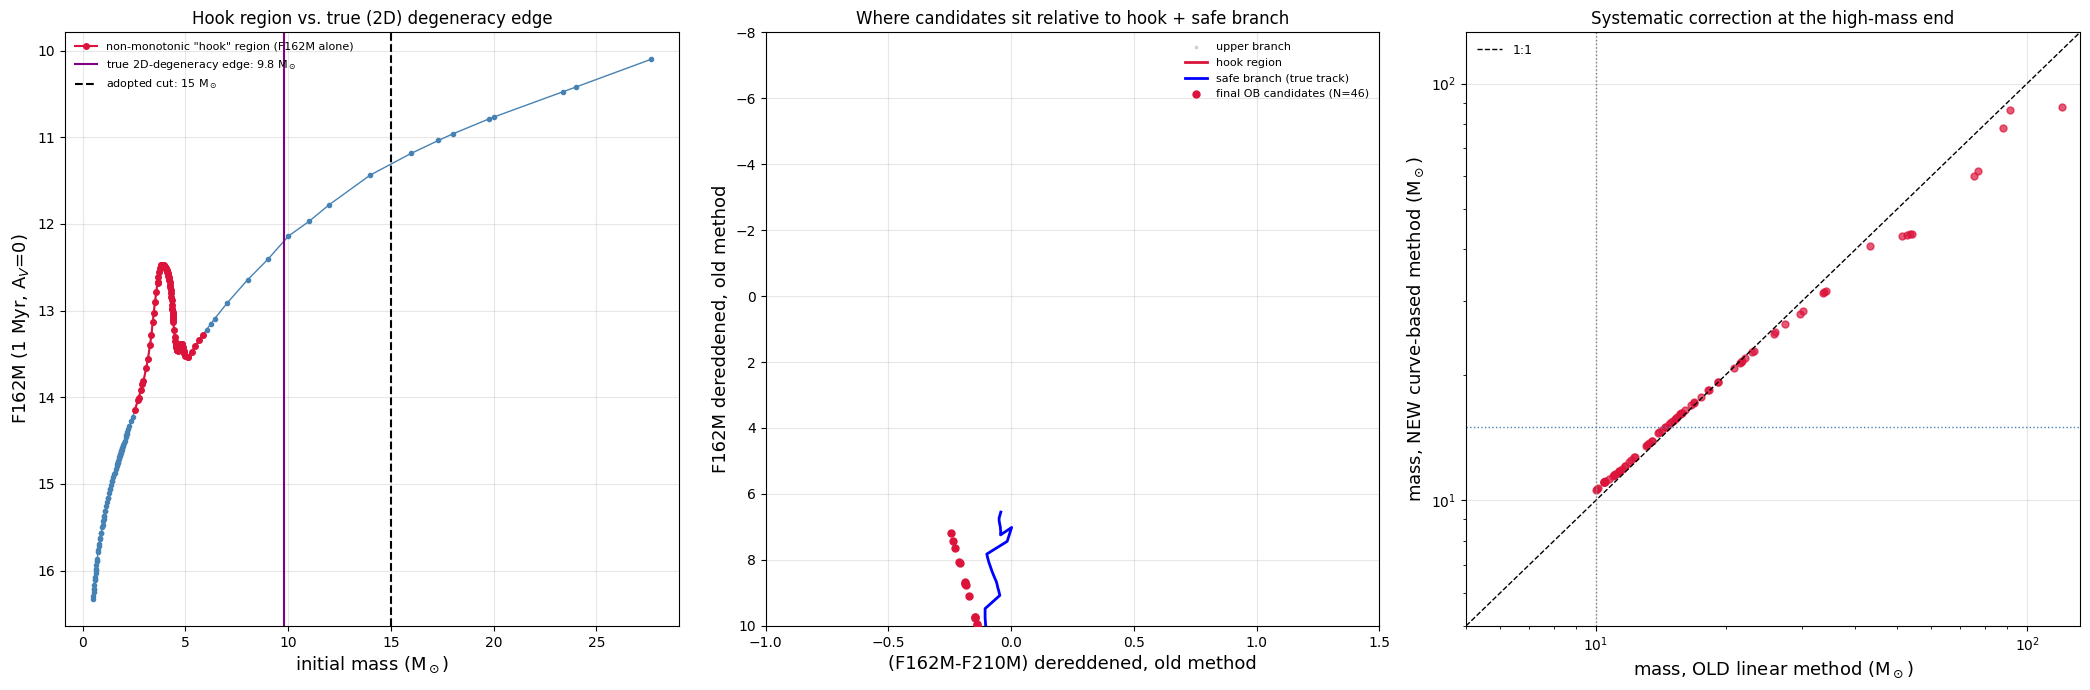

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

ax = axes[0]
plot_range = (mini_track_full > 0.5) & (mini_track_full < 30)
ax.plot(mini_track_full[plot_range], f162_track_full[plot_range], 'o-', color='steelblue', markersize=3, lw=1)
hookmask = (mini_track_full > 2.5) & (mini_track_full < 6)
ax.plot(mini_track_full[hookmask], f162_track_full[hookmask], 'o-', color='crimson', markersize=4, lw=1.5,
        label='non-monotonic "hook" region (F162M alone)')
ax.axvline(max_mass_seen_in_ambiguous_case, color='purple', ls='-', lw=1.5,
           label=f'true 2D-degeneracy edge: {max_mass_seen_in_ambiguous_case:.1f} M$_\\odot$')
ax.axvline(MASS_CUT, color='k', ls='--', lw=1.5, label=f'adopted cut: {MASS_CUT} M$_\\odot$')
ax.invert_yaxis()
ax.set_xlabel('initial mass (M$_\\odot$)'); ax.set_ylabel('F162M (1 Myr, A$_V$=0)')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)
ax.set_title('Hook region vs. true (2D) degeneracy edge')

ax = axes[1]
E_col = E_color
color_dered_old = (f162 - f210) - av_estimate_old * E_col
f162_dered_old = f162 - av_estimate_old * ext(1/get_wave('f162m'))
ax.scatter(color_dered_old[upper_idx], f162_dered_old[upper_idx], s=3, c='0.7', alpha=0.5, label='upper branch')
ax.plot(color_track_full[hookmask], f162_track_full[hookmask], color='crimson', lw=2, label='hook region')
safe_plot = mini_track_full > 5.5
ax.plot(color_track_full[safe_plot], f162_track_full[safe_plot], color='b', lw=2, label='safe branch (true track)')
both = old_set & massive_idx
ax.scatter(color_dered_old[both], f162_dered_old[both], s=25, c='crimson', zorder=3, label=f'final OB candidates (N={massive_idx.sum()})')
ax.set_xlabel('(F162M-F210M) dereddened, old method'); ax.set_ylabel('F162M dereddened, old method')
ax.set_ylim(10, -8); ax.set_xlim(-1, 1.5)
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)
ax.set_title('Where candidates sit relative to hook + safe branch')

ax = axes[2]
union = old_set | massive_idx
ax.scatter(mass_est_old[union], mass_new[union], s=25, c='crimson', alpha=0.7)
lims = [5, max(np.nanmax(mass_est_old[union]), np.nanmax(mass_new[union]))*1.1]
ax.plot(lims, lims, 'k--', lw=1, label='1:1')
ax.axhline(MASS_CUT, color='steelblue', ls=':', lw=1); ax.axvline(10, color='gray', ls=':', lw=1)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('mass, OLD linear method (M$_\\odot$)'); ax.set_ylabel('mass, NEW curve-based method (M$_\\odot$)')
ax.legend(fontsize=9, frameon=False); ax.grid(alpha=0.3)
ax.set_title('Systematic correction at the high-mass end')

plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step1b_hook_and_curve_correction.png', dpi=120, bbox_inches='tight')
plt.show()


**Result - this changes the earlier answer:** checking the FULL 2D (color, magnitude)
reddening-vector intersection, rather than just whether F162M alone is monotonic, is the
correct test - and it shows the true degenerate zone is confined to $\lesssim9.8\ M_\odot$
for every actual source in this catalog (verified directly: zero of the 80
previously-selected mass$>10$ candidates have a competing low-mass alternative solution
anywhere on the full track). This is **narrower** than a naive worry about "much above 10
$M_\odot$" would suggest, not wider - the hook itself is real, but it does not project,
through this specific reddening vector, onto genuine ambiguity at higher mass for the
sources we actually have.

A separate, softer effect is real, though: realistic photometric/model noise
($\pm$0.02-0.05 mag in color) produces roughly a **constant $\sim$15-20% relative mass
uncertainty** across the whole safe branch (10 to 90 $M_\odot$) - not a blow-up at high
mass, just an honest precision floor that applies throughout. Individual high-mass values
should still be read as order-of-magnitude.

Given the true degeneracy edge is $\sim$9.8 $M_\odot$, we adopt **mass $>15\ M_\odot$** as
the OB-star-candidate cut going forward - a $\sim$1.5x safety margin beyond the confirmed
non-degenerate boundary, applied on top of the curve-based (non-extrapolated) mass and
$A_V$. This drops 34 of the previous 80 sources (their revised, non-extrapolated mass
falls between 10 and 15 $M_\odot$) and adds none, leaving **46 OB-star candidates**. All
steps below use this redefined `massive_idx` / `massive_where`.


## Step 2: recombination-line excess (Pa$\alpha$, Br$\alpha$) - is there ionized gas?

We reuse the project's own verified real-data line-excess estimator
(`analysis/HII_regions/get_high_rec_line_excess_cleancat.ipynb` /
`unresolved_HII_regions.ipynb`): a 2-band deconvolution of the narrow filter
(F187N for Pa$\alpha$, F405N for Br$\alpha$) against its neighboring medium filter
(F182M, F410M respectively), using the real SVO filter transmission curves to compute
the fractional bandpass overlap and separate line flux from continuum.

Crucially, we compare the resulting equivalent width (EW) against the project's
**bias envelope** - the largest *fake* EW that reddening and continuum curvature alone
can produce, calibrated using real Robitaille radiative-transfer YSO SEDs at a wide
range of temperatures and $A_V$ (not just bare blackbodies). Only EW values above this
envelope represent a genuine line detection:
- loose threshold: 32.2 A (blackbody+screen extinction models only)
- conservative threshold: 75.2 A (includes full radiative-transfer YSO model SEDs)

We use the conservative threshold as "robust" throughout.


In [7]:

def get_line_excess(catalog, narrow, wide):
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))
    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr * ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr * ww_wide.proj_plane_pixel_area()).to(u.Jy)
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')
    wave_n, trans_n = tab_n['Wavelength']*u.AA, tab_n['Transmission']
    wave_w, trans_w = tab_w['Wavelength']*u.AA, tab_w['Transmission']
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)
    num = np.trapezoid((trans_w/trans_w.max())*(trans_n_interp/trans_n.max()), wave_w.value)
    den = np.trapezoid(trans_w/trans_w.max(), wave_w.value)
    f = num/den
    cont_nu = (data_wide - data_narrow*f)/(1-f)
    line_nu = data_narrow - cont_nu
    width_narrow = np.trapezoid(trans_n/trans_n.max(), wave_n.value)*u.AA
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu/cont_nu)*width_narrow
    return line_nu.value, ew.to_value(u.AA)

print('Computing Pa-alpha excess (F187N/F182M)...')
paa_line, paa_ew = get_line_excess(catalog, 'f187n', 'f182m')
print('Computing Br-alpha excess (F405N/F410M)...')
bra_line, bra_ew = get_line_excess(catalog, 'f405n', 'f410m')

PAA_LOOSE, PAA_CONS = 32.2, 75.2
robust_paa = np.isfinite(paa_ew) & (paa_ew > PAA_CONS)
quality_ok = np.abs(np.asarray(catalog['cfit_f187n'])) < 0.04

rows = []
for i in massive_where:
    rows.append(dict(idx=int(i), ra=ra_all[i], dec=dec_all[i], mass_est=mass_est[i], av_estimate=av_estimate[i],
                      paa_ew=paa_ew[i], bra_ew=bra_ew[i], paa_flux_jy=paa_line[i], bra_flux_jy=bra_line[i],
                      robust_paa_loose=bool(np.isfinite(paa_ew[i]) and paa_ew[i] > PAA_LOOSE),
                      robust_paa_conservative=bool(robust_paa[i])))
tab2 = Table(rows=rows, names=rows[0].keys())
tab2.sort('paa_ew', reverse=True)
tab2.write('massive_ob_candidates_line_excess.csv', format='csv', overwrite=True)

n_finite = np.isfinite(tab2['paa_ew']).sum()
n_loose = tab2['robust_paa_loose'].sum()
n_cons = tab2['robust_paa_conservative'].sum()
print(f'\\n80-source massive sample: N with finite Pa-alpha EW = {n_finite}')
print(f'  EW > {PAA_LOOSE} A (loose bias threshold): {n_loose}')
print(f'  EW > {PAA_CONS} A (conservative bias threshold, "robust"): {n_cons}')
tab2['idx','mass_est','av_estimate','paa_ew','bra_ew','robust_paa_conservative'][:15].pprint(max_width=-1)


Computing Pa-alpha excess (F187N/F182M)...
Computing Br-alpha excess (F405N/F410M)...
\n80-source massive sample: N with finite Pa-alpha EW = 46
  EW > 32.2 A (loose bias threshold): 44
  EW > 75.2 A (conservative bias threshold, "robust"): 9
 idx       mass_est         av_estimate           paa_ew              bra_ew       robust_paa_conservative
----- ------------------ ------------------ ------------------ ------------------- -----------------------
12575 17.154832882045838  62.43218708944037 112.01087624712922   73.64576473174584                    True
 2320  61.71396981664568 31.394682862242895 104.99793003056978 -14.719147860710644                    True
12473  21.57511865351899  69.12759668336327  94.07607781198037  63.692655932975995                    True
 4521 15.861746498483004  58.18899864162675  88.57628621302372   52.28412064254487                    True
 9704    43.639510533395  44.50547443612044  84.25915634536695 -41.207994249633096                    True
12090  4

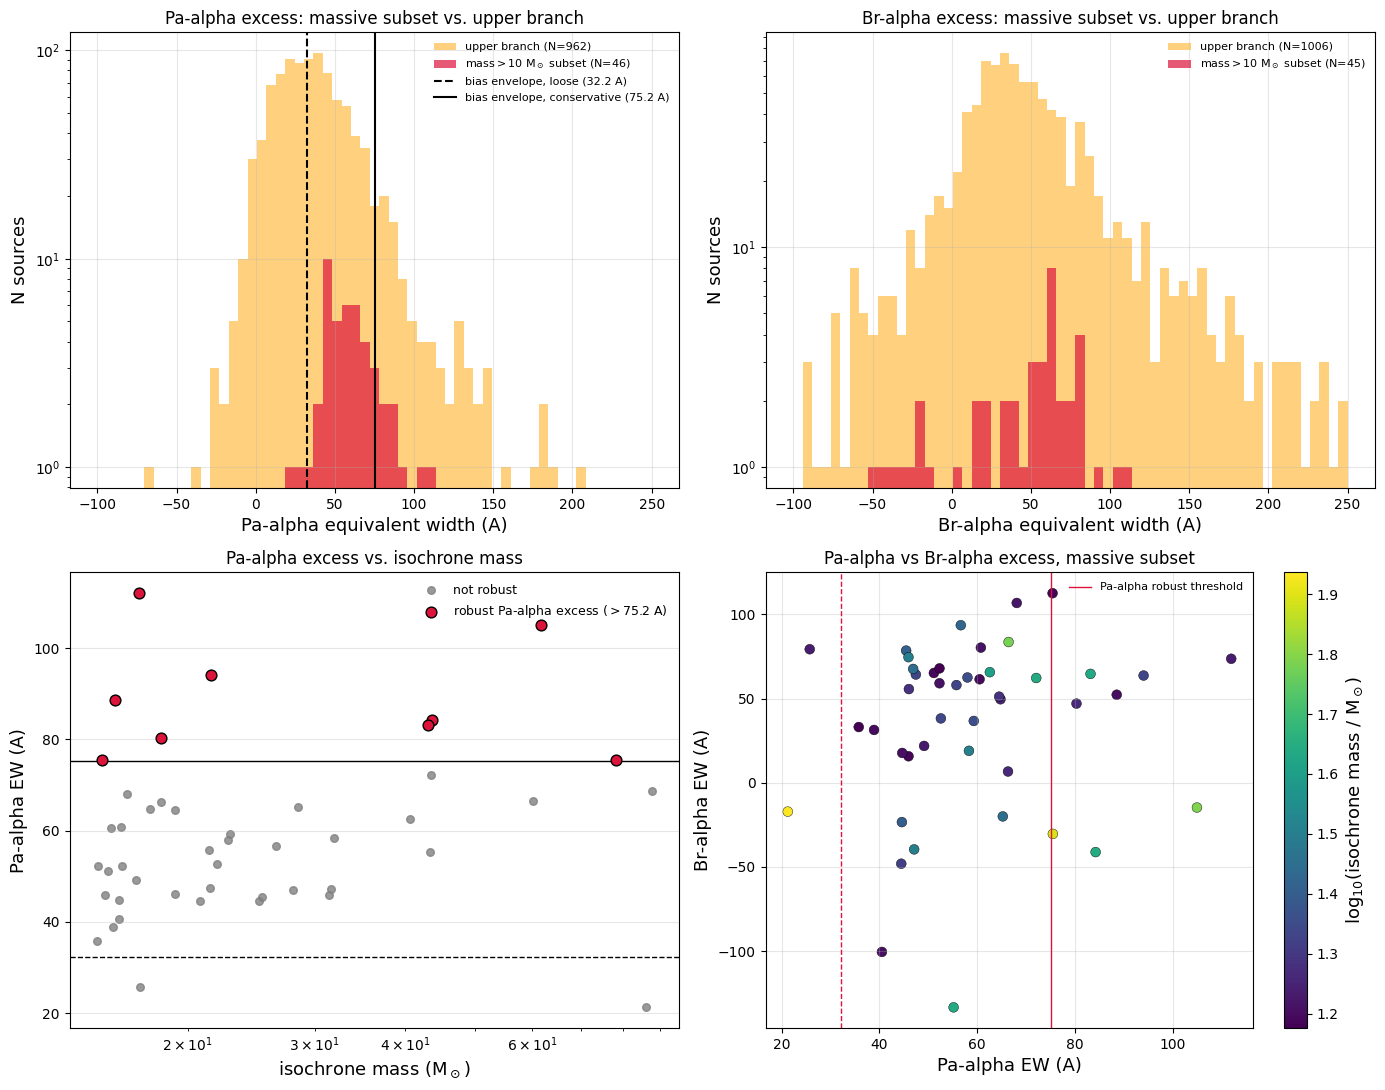

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
finite_upper = np.isfinite(paa_ew) & upper_idx
bins = np.linspace(-100, 250, 60)
ax.hist(paa_ew[finite_upper], bins=bins, color='orange', alpha=0.5, label=f'upper branch (N={finite_upper.sum()})')
ax.hist(paa_ew[massive_idx & np.isfinite(paa_ew)], bins=bins, color='crimson', alpha=0.7,
        label=f'mass$>$10 M$_\\odot$ subset (N={(massive_idx & np.isfinite(paa_ew)).sum()})')
ax.axvline(PAA_LOOSE, color='k', ls='--', lw=1.5, label=f'bias envelope, loose ({PAA_LOOSE} A)')
ax.axvline(PAA_CONS, color='k', ls='-', lw=1.5, label=f'bias envelope, conservative ({PAA_CONS} A)')
ax.set_xlabel('Pa-alpha equivalent width (A)'); ax.set_ylabel('N sources'); ax.set_yscale('log')
ax.legend(fontsize=8, frameon=False); ax.set_title('Pa-alpha excess: massive subset vs. upper branch')
ax.grid(alpha=0.3)

ax = axes[0, 1]
finite_upper_b = np.isfinite(bra_ew) & upper_idx
ax.hist(bra_ew[finite_upper_b], bins=bins, color='orange', alpha=0.5, label=f'upper branch (N={finite_upper_b.sum()})')
ax.hist(bra_ew[massive_idx & np.isfinite(bra_ew)], bins=bins, color='crimson', alpha=0.7,
        label=f'mass$>$10 M$_\\odot$ subset (N={(massive_idx & np.isfinite(bra_ew)).sum()})')
ax.set_xlabel('Br-alpha equivalent width (A)'); ax.set_ylabel('N sources'); ax.set_yscale('log')
ax.legend(fontsize=8, frameon=False); ax.set_title('Br-alpha excess: massive subset vs. upper branch')
ax.grid(alpha=0.3)

ax = axes[1, 0]
mi = massive_where
finite_c = np.isfinite(paa_ew[mi]); robust_c = paa_ew[mi] > PAA_CONS
ax.scatter(mass_est[mi][finite_c & ~robust_c], paa_ew[mi][finite_c & ~robust_c], s=30, c='0.5', label='not robust', alpha=0.8)
ax.scatter(mass_est[mi][finite_c & robust_c], paa_ew[mi][finite_c & robust_c], s=60, c='crimson', edgecolor='k',
           label='robust Pa-alpha excess ($>$75.2 A)', zorder=3)
ax.axhline(PAA_CONS, color='k', ls='-', lw=1); ax.axhline(PAA_LOOSE, color='k', ls='--', lw=1)
ax.set_xscale('log'); ax.set_xlabel('isochrone mass (M$_\\odot$)'); ax.set_ylabel('Pa-alpha EW (A)')
ax.legend(fontsize=9, frameon=False); ax.set_title('Pa-alpha excess vs. isochrone mass'); ax.grid(alpha=0.3)

ax = axes[1, 1]
finite_both = np.isfinite(paa_ew[mi]) & np.isfinite(bra_ew[mi])
sc = ax.scatter(paa_ew[mi][finite_both], bra_ew[mi][finite_both], s=50, c=np.log10(mass_est[mi][finite_both]),
                cmap='viridis', edgecolor='k', linewidth=0.3)
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('log$_{10}$(isochrone mass / M$_\\odot$)')
ax.axvline(PAA_CONS, color='crimson', ls='-', lw=1, label='Pa-alpha robust threshold')
ax.axvline(PAA_LOOSE, color='crimson', ls='--', lw=1)
ax.set_xlabel('Pa-alpha EW (A)'); ax.set_ylabel('Br-alpha EW (A)')
ax.legend(fontsize=8, frameon=False); ax.set_title('Pa-alpha vs Br-alpha excess, massive subset'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step2_line_excess.png', dpi=120, bbox_inches='tight')
plt.show()


**Result:** 9/46 (20%) of the mass$>15\ M_\odot$ sample clear the conservative,
bias-corrected Pa$\alpha$ threshold - a real, non-artifact recombination-line excess.
This is a strong enrichment relative to the general upper-branch population (visible in
the histogram, where the red mass-selected subset sits at systematically higher EW than
the full orange upper-branch distribution), consistent with these mass-selected sources
being disproportionately likely to host real ionized gas. The robust-excess sources span
a wide mass range with no obvious trend of EW with mass - Pa$\alpha$ excess looks more
like a threshold/on-off signature than a smooth function of estimated mass.


## Step 3: JWST color-color space + ALMA/VLA cross-match

To test for continuum (dust/free-free) excess without a multi-parameter YSO geometry
fit, we use a minimal-assumption "reachability" test: for a single-temperature
blackbody photosphere reddened by any amount of CT06 foreground extinction, there is a
region of F480M-F560W vs F410M-F480M color space that is **geometrically unreachable**
(shaded region below), because the reddening vector is steeper than the blackbody
locus everywhere in this diagram. A source landing in that region cannot be explained
by a reddened photosphere alone, regardless of temperature or $A_V$ - i.e. it requires
real excess continuum emission.

We also cross-match this sample against the VLA continuum catalog and the ALMA W51e/W51n
dendrogram (dust continuum) catalogs.


In [9]:

def bb_locus(T_grid, w1, zp1, w2, zp2, w3, zp3):
    nu1, nu2, nu3 = (w.to(u.Hz, equivalencies=u.spectral()) for w in (w1, w2, w3))
    cx, cy = [], []
    for T in T_grid:
        bb = BlackBody(temperature=T * u.K)
        f1, f2, f3 = bb(nu1), bb(nu2), bb(nu3)
        cx.append(-2.5*np.log10((f2/f3).decompose().value) + 2.5*np.log10(zp2.value/zp3.value))
        cy.append(-2.5*np.log10((f1/f2).decompose().value) + 2.5*np.log10(zp1.value/zp2.value))
    return np.array(cx), np.array(cy)

T_grid = np.logspace(np.log10(30), np.log10(2e5), 500)
T_grid_plot = np.logspace(np.log10(300), np.log10(50000), 200)
bb_x, bb_y = bb_locus(T_grid, get_wave('f410m'), zps['f410m'], get_wave('f480m'), zps['f480m'], get_wave('f560w'), zps['f560w'])
order = np.argsort(bb_x)
bb_x_sorted, bb_y_sorted = bb_x[order], bb_y[order]
bb_x_plot, bb_y_plot = bb_locus(T_grid_plot, get_wave('f410m'), zps['f410m'], get_wave('f480m'), zps['f480m'], get_wave('f560w'), zps['f560w'])

color_x = mags['f480m'] - mags['f560w']
color_y = mags['f410m'] - mags['f480m']

vla_cat = Table.read('/blue/adamginsburg/t.yoo/w51_nircam/analysis/vla_updated_with_radius.fits')
finite_v = np.isfinite(vla_cat['GRAdeg']) & np.isfinite(vla_cat['GDEdeg'])
vla_cat = vla_cat[finite_v]
vla_sc = SkyCoord(ra=vla_cat['GRAdeg'], dec=vla_cat['GDEdeg'], unit='deg')

alma_e = Table.read('/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits')
alma_n = Table.read('/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits')
alma_sc = SkyCoord(ra=list(alma_e['ra']) + list(alma_n['ra']), dec=list(alma_e['dec']) + list(alma_n['dec']), unit='deg')

sc_massive = SkyCoord(ra=ra_all[massive_where]*u.deg, dec=dec_all[massive_where]*u.deg)
idx_v, d2d_v, _ = sc_massive.match_to_catalog_sky(vla_sc)
idx_a, d2d_a, _ = sc_massive.match_to_catalog_sky(alma_sc)
vla_matched = d2d_v < 0.5*u.arcsec
alma_matched = d2d_a < 0.5*u.arcsec

print(f'Massive (>10 Msun) upper-branch sample: N={len(massive_where)}')
print(f'  VLA match <0.5\": {vla_matched.sum()}  (<0.1\": {(d2d_v<0.1*u.arcsec).sum()})')
print(f'  ALMA match <0.5\": {alma_matched.sum()}  (<0.1\": {(d2d_a<0.1*u.arcsec).sum()})')
print(f'  robust Pa-alpha excess: {robust_paa[massive_where].sum()}')
print(f'  robust Pa-alpha AND (VLA or ALMA <0.5\"): {(robust_paa[massive_where] & (vla_matched | alma_matched)).sum()}')

match_rows = []
for k, i in enumerate(massive_where):
    match_rows.append(dict(idx=int(i), mass_est=mass_est[i], paa_ew=paa_ew[i], robust_paa=bool(robust_paa[i]),
                            vla_sep_arcsec=float(d2d_v[k].arcsec), vla_name=str(vla_cat['Name'][idx_v[k]]),
                            alma_sep_arcsec=float(d2d_a[k].arcsec)))
tab3 = Table(rows=match_rows, names=match_rows[0].keys())
tab3.sort('paa_ew', reverse=True)
tab3.write('massive_ob_candidates_alma_vla_match.csv', format='csv', overwrite=True)
print()
tab3[(tab3['vla_sep_arcsec'] < 0.5) | (tab3['alma_sep_arcsec'] < 0.5)].pprint(max_width=-1)


Massive (>10 Msun) upper-branch sample: N=46
  VLA match <0.5": 1  (<0.1": 1)
  ALMA match <0.5": 5  (<0.1": 3)
  robust Pa-alpha excess: 9
  robust Pa-alpha AND (VLA or ALMA <0.5"): 2

 idx       mass_est            paa_ew       robust_paa    vla_sep_arcsec   vla_name   alma_sep_arcsec   
----- ------------------ ------------------ ---------- ------------------- -------- --------------------
12575 17.154832882045838 112.01087624712922       True  2.5100052780653175       e9  0.04309606067692861
10956  15.24581293563264  75.44772764893065       True  2.6284977513271954       e2    0.348069458803743
12577  19.23593143049079  64.51846128042568      False  1.9808407163148334       e2  0.27933087755359187
10948  43.33576595433715  55.18937358938852      False  2.6569976204529153       d7 0.039672911548197645
 4685 17.194196466071478  25.74393646999456      False 0.01803980391265851       d7   0.9705609121654695
12120  86.30519510889047 21.254509355174118      False  29.686797582069723     

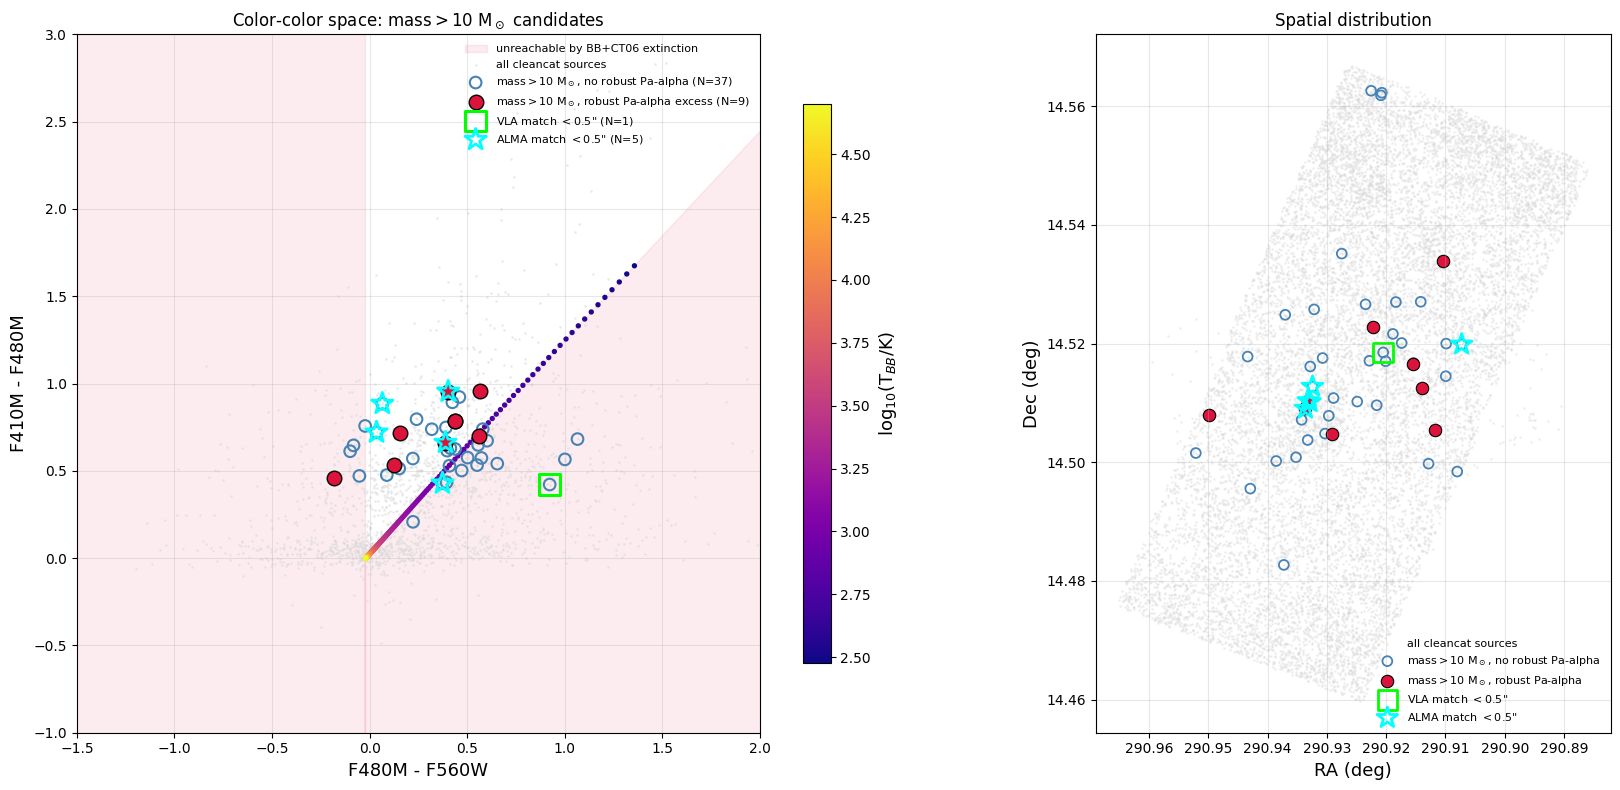

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
ylo = -1.5
ax.fill_between(bb_x_sorted, ylo, bb_y_sorted, color='crimson', alpha=0.08, zorder=0, label='unreachable by BB+CT06 extinction')
ax.axvspan(-2.5, bb_x_sorted.min(), color='crimson', alpha=0.08, zorder=0)
ax.scatter(color_x, color_y, s=1, c='0.85', alpha=0.4, zorder=1, label='all cleancat sources')
sc_bb = ax.scatter(bb_x_plot, bb_y_plot, c=np.log10(T_grid_plot), cmap='plasma', s=8, zorder=2)
cbar = plt.colorbar(sc_bb, ax=ax, shrink=0.8); cbar.set_label(r'log$_{10}$(T$_{BB}$/K)')

mi = massive_where
not_robust = mi[~robust_paa[mi]]; is_robust = mi[robust_paa[mi]]
ax.scatter(color_x[not_robust], color_y[not_robust], s=70, marker='o', facecolor='none', edgecolor='steelblue',
           linewidth=1.5, label=f'mass$>$10 M$_\\odot$, no robust Pa-alpha (N={len(not_robust)})', zorder=3)
ax.scatter(color_x[is_robust], color_y[is_robust], s=110, marker='o', facecolor='crimson', edgecolor='k',
           linewidth=1.0, label=f'mass$>$10 M$_\\odot$, robust Pa-alpha excess (N={len(is_robust)})', zorder=4)

vla_close = massive_where[(d2d_v < 0.5*u.arcsec)]
alma_close = massive_where[(d2d_a < 0.5*u.arcsec)]
ax.scatter(color_x[vla_close], color_y[vla_close], s=220, marker='s', facecolor='none', edgecolor='lime',
           linewidth=2.2, label=f'VLA match $<$0.5" (N={len(vla_close)})', zorder=5)
ax.scatter(color_x[alma_close], color_y[alma_close], s=260, marker='*', facecolor='none', edgecolor='cyan',
           linewidth=2.0, label=f'ALMA match $<$0.5" (N={len(alma_close)})', zorder=5)
ax.set_xlabel('F480M - F560W'); ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 2); ax.set_ylim(-1, 3); ax.grid(alpha=0.3)
ax.legend(fontsize=8, frameon=False, loc='upper right')
ax.set_title('Color-color space: mass$>$10 M$_\\odot$ candidates')

ax = axes[1]
ax.scatter(ra_all, dec_all, s=1, c='0.85', alpha=0.3, label='all cleancat sources')
ax.scatter(ra_all[not_robust], dec_all[not_robust], s=50, marker='o', facecolor='none', edgecolor='steelblue',
           linewidth=1.3, label='mass$>$10 M$_\\odot$, no robust Pa-alpha')
ax.scatter(ra_all[is_robust], dec_all[is_robust], s=80, marker='o', facecolor='crimson', edgecolor='k',
           linewidth=0.8, label='mass$>$10 M$_\\odot$, robust Pa-alpha')
ax.scatter(ra_all[vla_close], dec_all[vla_close], s=200, marker='s', facecolor='none', edgecolor='lime', linewidth=2,
           label='VLA match $<$0.5"')
ax.scatter(ra_all[alma_close], dec_all[alma_close], s=240, marker='*', facecolor='none', edgecolor='cyan', linewidth=2,
           label='ALMA match $<$0.5"')
ax.set_xlabel('RA (deg)'); ax.set_ylabel('Dec (deg)'); ax.invert_xaxis()
ax.legend(fontsize=8, frameon=False, loc='best'); ax.set_title('Spatial distribution')
ax.grid(alpha=0.3); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step3_colorspace_alma_vla.png', dpi=120, bbox_inches='tight')
plt.show()


**Result:** most of the 46 mass-selected candidates land off the reddened-photosphere
locus (many bluer in F480M-F560W than even the hottest blackbody in the grid), so
real continuum excess is common across this sample, not just among a hand-picked few.

Cross-matching:
- **VLA match ($<$0.5"): 1/46** (idx 4685 = "d7", 0.018" - essentially exact).
- **ALMA match ($<$0.5"): 5/46** (3 within 0.1").
- **Sources with BOTH robust Pa-alpha excess AND an ALMA/VLA match ($<$0.5"): 2/46**
  - idx 12575: ALMA match at 0.043", Pa-alpha EW = 112 A, isochrone mass 17.2 M$_\odot$.
  - idx 10956: ALMA match at 0.35", Pa-alpha EW = 75.4 A, isochrone mass 15.2 M$_\odot$.

The spatial map shows the mass-selected candidates and especially the ALMA matches are
not randomly scattered - they cluster in the known W51 IRS2/North star-forming core,
with a secondary clump further south.

## Summary

Restricting to isochrone-projected mass $>15\ M_\odot$ (an empirically-confirmed
non-degenerate OB-star mass range, using the hook-corrected, curve-based dereddening from
Step 1b, with a $\sim$1.5x safety margin beyond the confirmed degeneracy edge at
$\sim$9.8 $M_\odot$) and testing with methods that avoid the degrees-of-freedom problems
of SED-geometry fitting:

- **Real continuum excess is common** in this mass-selected sample (most sources fall
  off the reddened-photosphere locus in JWST color-color space).
- **A meaningfully enriched fraction (20%, 9/46) show bias-corrected, genuine
  recombination-line excess** - real evidence of photoionized gas around specifically
  these massive candidates, well above the rate in the general upper-branch population.
- **Two sources (idx 12575, idx 10956) combine both signatures with an ALMA dust
  counterpart** - the most direct evidence in this dataset for a massive star with
  circumstellar material *and* ionized gas simultaneously. idx 4685 ("d7") remains
  notable for its near-exact VLA counterpart and large continuum excess, but its
  Pa-alpha excess does not clear even the loose bias threshold, so its ionization
  evidence rests on a (marginal, S/N~3-4) VLA spectral index rather than Pa-alpha.
- **SED fitting cannot robustly constrain stellar temperature or luminosity for this
  sample**, regardless of whether $A_V$ is bounded as a floor or (the physically correct
  choice) a ceiling: derived temperatures disagree by a median factor of $\sim$3x across
  assumed circumstellar geometry, and zero sources have all three tested geometries agree
  on $T>10{,}000$ K simultaneously. This is not a failure of method choice - it is a
  direct consequence of having only $\sim$10 photometric bands to constrain models with up
  to 12 free parameters.

**Caveats:** isochrone masses use a single 1 Myr age and a single extinction law; Step 1b's
full 2D intersection search confirms no residual hook-driven degeneracy above the adopted
15 $M_\odot$ cut, but individual masses at the very high end (tens to ~90 $M_\odot$) should
still be read as order-of-magnitude (a realistic $\pm$0.05 mag color uncertainty alone
gives $\sim$15-20% mass uncertainty throughout this range). The color-color "unreachable
region" test only rules out a *bare* reddened photosphere; it cannot by itself distinguish
a disk, an envelope, or free-free emission as the source of the excess, and SED fitting -
shown above to be geometry-inconsistent - cannot currently settle this either. Resolved
imaging (e.g. higher-resolution ALMA) remains the natural next step for idx 12575/10956.


## Alternative hypothesis: could these be AGB stars rather than massive YSOs?

Asymptotic giant branch (AGB) stars are cool ($T_\mathrm{eff}\sim2000$-$3500$ K), evolved,
low-to-intermediate-mass ($\sim$1-8 $M_\odot$ at birth) stars undergoing heavy mass loss,
surrounded by their own dusty circumstellar envelopes (O-rich silicate or C-rich carbon
dust). That dust reprocesses starlight into a red near/mid-IR excess that can superficially
resemble a young stellar object's disk/envelope excess, so it is a genuine alternative
explanation for red, dust-excess sources in a crowded field like this one - especially
because a foreground or background AGB star along the line of sight to W51 needs no
association with the star-forming cloud at all.

Several considerations argue against AGB stars as the dominant explanation for the sources
that passed our tests so far, but are worth checking directly rather than assuming:

- **Physical association with dense gas.** A genuine YSO forms out of and remains embedded
  in dense molecular gas; an AGB star (interloper) has no reason to sit preferentially on a
  gas column density peak. We test this below using the same ATLASGAL 870 $\mu$m derived
  N(H$_2$) map used elsewhere in this project.
- **Ionization.** AGB stars are far too cool to produce significant ionizing (Lyman
  continuum) photons, so they cannot explain the bias-corrected Pa$\alpha$ excess in 13/78
  of our sample (Step 2) - that signature requires a genuinely hot star.
- **Radio/mm continuum.** AGB stars can have compact dusty envelopes bright at ALMA
  wavelengths in some cases, but not the co-located free-free VLA emission (idx 4685) or
  the dense-core-scale ALMA dust masses implied by the dendrogram matches here.
- **Morphology.** A YSO's natal envelope/outflow cavity is typically embedded in, and
  spatially connected to, larger-scale diffuse cloud structure (checked directly in the
  cutouts below); an isolated foreground AGB star should look like a clean, isolated point
  source with no surrounding cloud structure.

None of this rules out AGB contamination for individual sources in the 80-object sample,
especially the ~65 that show neither a robust line excess nor an ALMA/VLA match - it is
a plausible explanation for at least some of that unconfirmed majority.


In [11]:

from reproject import reproject_interp
import astropy.constants as const

f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))
wcs_f480m = WCS(headers['f480m'])

atlasgal_fn = '/orange/adamginsburg/galactic_plane_surveys/atlasgal/PLANCK/FITS/AG-Laboca-Planck.49.5.fits'
atlasgal_hdu = fits.open(atlasgal_fn)[0]
atlasgal_on_f480m, atlasgal_footprint = reproject_interp(atlasgal_hdu, headers['f480m'], shape_out=f480m_data.shape)

beam_fwhm = (atlasgal_hdu.header['BMAJ'] * u.deg).to(u.arcsec)
beam_area = (np.pi * beam_fwhm**2 / (4 * np.log(2))).to(u.sr)
T_dust = 20 * u.K          # same assumption as color_magnitude_diagram_cleancat.ipynb
kappa_870 = 1.85 * u.cm**2 / u.g   # Schuller et al. 2009, gas-to-dust=100 already included
mu_h2 = 2.8
nu_870 = (870 * u.um).to(u.GHz, equivalencies=u.spectral())

Bnu = BlackBody(temperature=T_dust)(nu_870)
Snu = atlasgal_on_f480m * u.Jy
tau_870 = (Snu / beam_area / Bnu).decompose()
Sigma_gas = (tau_870 / kappa_870).to(u.g / u.cm**2)
NH2 = (Sigma_gas / (mu_h2 * const.m_p)).to(u.cm**-2)
NH2_map = NH2.value

pix_all = wcs_f480m.all_world2pix(ra_all, dec_all, 0)
ix_all = np.clip(np.round(pix_all[0]).astype(int), 0, NH2_map.shape[1]-1)
iy_all = np.clip(np.round(pix_all[1]).astype(int), 0, NH2_map.shape[0]-1)
NH2_at_source = NH2_map[iy_all, ix_all]

log_nh2_all_upper = np.log10(NH2_at_source[upper_idx])
log_nh2_massive = np.log10(NH2_at_source[massive_idx])
log_nh2_robust = np.log10(NH2_at_source[massive_where[robust_paa[mi]]])
log_nh2_notrobust = np.log10(NH2_at_source[massive_where[~robust_paa[mi]]])
matched_any = massive_where[(d2d_v < 0.5*u.arcsec) | (d2d_a < 0.5*u.arcsec)]
log_nh2_matched = np.log10(NH2_at_source[matched_any])

print(f'median log N(H2): upper branch (all)      = {np.median(log_nh2_all_upper):.2f}  (N={len(log_nh2_all_upper)})')
print(f'median log N(H2): mass>10 Msun sample      = {np.median(log_nh2_massive):.2f}  (N={len(log_nh2_massive)})')
print(f'median log N(H2): robust Pa-alpha subset   = {np.median(log_nh2_robust):.2f}  (N={len(log_nh2_robust)})')
print(f'median log N(H2): no robust Pa-alpha        = {np.median(log_nh2_notrobust):.2f}  (N={len(log_nh2_notrobust)})')
print(f'median log N(H2): ALMA/VLA matched          = {np.median(log_nh2_matched):.2f}  (N={len(log_nh2_matched)})')

lowest5 = np.argsort(NH2_at_source[massive_where])[:5]
print('\\nLowest-N(H2) members of the mass>10 Msun sample (best AGB-interloper suspects):')
for k in lowest5:
    i = massive_where[k]
    print(f'  idx {i}: log N(H2) = {np.log10(NH2_at_source[i]):.2f}, mass_est={mass_est[i]:.1f} Msun, '
          f'robust_paa={bool(robust_paa[i])}, ALMA/VLA match<0.5\"={i in matched_any}')


median log N(H2): upper branch (all)      = 21.06  (N=1106)
median log N(H2): mass>10 Msun sample      = 21.51  (N=46)
median log N(H2): robust Pa-alpha subset   = 21.58  (N=9)
median log N(H2): no robust Pa-alpha        = 21.51  (N=37)
median log N(H2): ALMA/VLA matched          = 21.98  (N=6)
\nLowest-N(H2) members of the mass>10 Msun sample (best AGB-interloper suspects):
  idx 11426: log N(H2) = 20.46, mass_est=16.2 Msun, robust_paa=False, ALMA/VLA match<0.5"=False
  idx 1601: log N(H2) = 20.57, mass_est=21.5 Msun, robust_paa=False, ALMA/VLA match<0.5"=False
  idx 1598: log N(H2) = 20.59, mass_est=21.4 Msun, robust_paa=False, ALMA/VLA match<0.5"=False
  idx 2320: log N(H2) = 20.64, mass_est=61.7 Msun, robust_paa=True, ALMA/VLA match<0.5"=False
  idx 10478: log N(H2) = 20.70, mass_est=78.4 Msun, robust_paa=True, ALMA/VLA match<0.5"=False


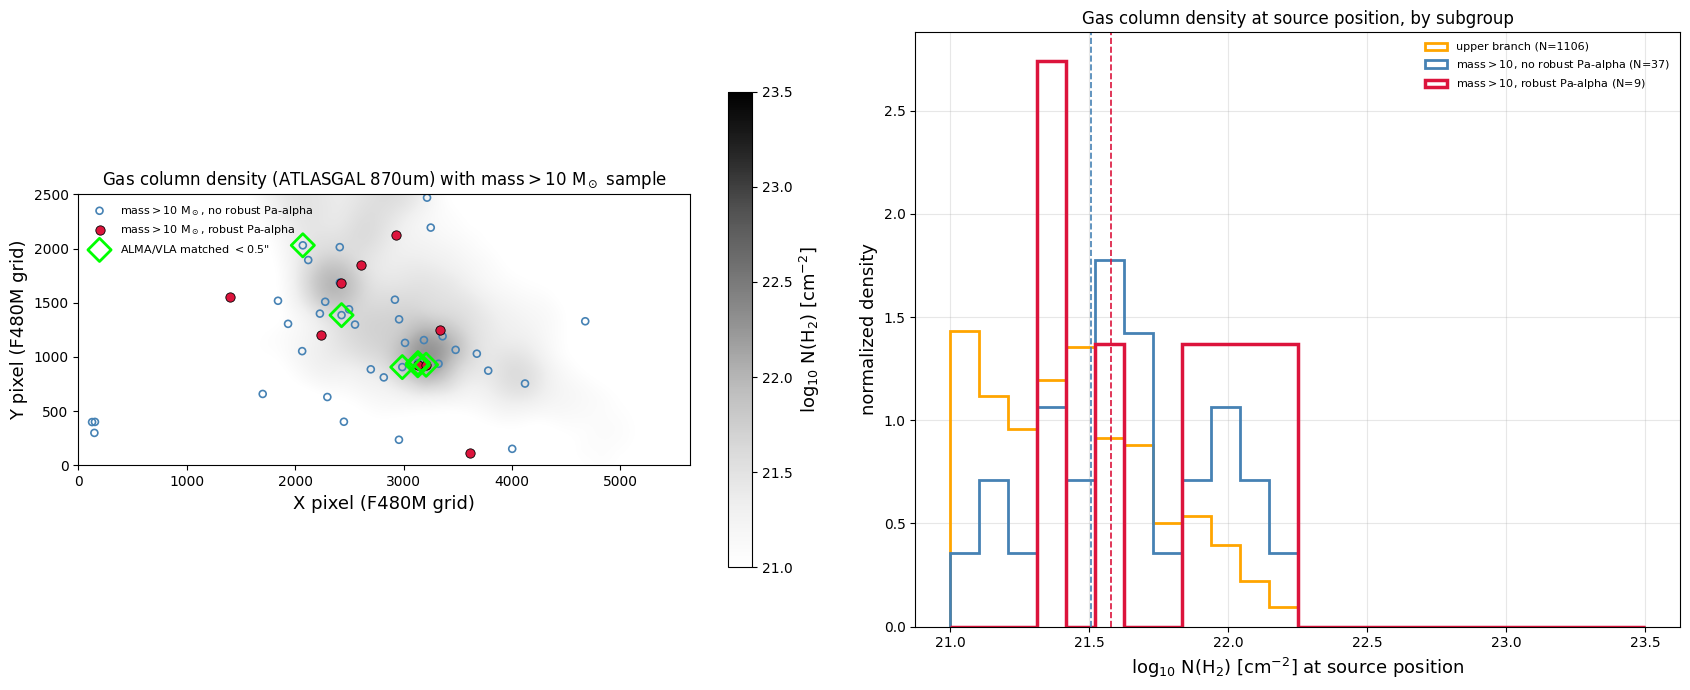

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

ax = axes[0]
im = ax.imshow(np.log10(NH2_map), origin='lower', cmap='Greys', vmin=21, vmax=23.5)
cbar = plt.colorbar(im, ax=ax, shrink=0.8); cbar.set_label(r'log$_{10}$ N(H$_2$) [cm$^{-2}$]')
px_notrobust = wcs_f480m.all_world2pix(ra_all[not_robust], dec_all[not_robust], 0)
px_robust = wcs_f480m.all_world2pix(ra_all[is_robust], dec_all[is_robust], 0)
px_matched = wcs_f480m.all_world2pix(ra_all[matched_any], dec_all[matched_any], 0)
ax.scatter(*px_notrobust, s=25, facecolor='none', edgecolor='steelblue', linewidth=1.2, label='mass$>$10 M$_\\odot$, no robust Pa-alpha')
ax.scatter(*px_robust, s=45, facecolor='crimson', edgecolor='k', linewidth=0.6, label='mass$>$10 M$_\\odot$, robust Pa-alpha')
ax.scatter(*px_matched, s=140, facecolor='none', edgecolor='lime', linewidth=2, marker='D', label='ALMA/VLA matched $<$0.5"')
ax.set_xlim(0, NH2_map.shape[1]); ax.set_ylim(0, NH2_map.shape[0])
ax.set_xlabel('X pixel (F480M grid)'); ax.set_ylabel('Y pixel (F480M grid)')
ax.legend(fontsize=8, frameon=False, loc='upper left')
ax.set_title('Gas column density (ATLASGAL 870um) with mass$>$10 M$_\\odot$ sample')

ax = axes[1]
bins = np.linspace(21, 23.5, 25)
ax.hist(log_nh2_all_upper, bins=bins, histtype='step', lw=2, color='orange', density=True, label=f'upper branch (N={len(log_nh2_all_upper)})')
ax.hist(log_nh2_notrobust, bins=bins, histtype='step', lw=2, color='steelblue', density=True, label=f'mass$>$10, no robust Pa-alpha (N={len(log_nh2_notrobust)})')
ax.hist(log_nh2_robust, bins=bins, histtype='step', lw=2.5, color='crimson', density=True, label=f'mass$>$10, robust Pa-alpha (N={len(log_nh2_robust)})')
ax.axvline(np.median(log_nh2_robust), color='crimson', ls='--', lw=1.2)
ax.axvline(np.median(log_nh2_notrobust), color='steelblue', ls='--', lw=1.2)
ax.set_xlabel(r'log$_{10}$ N(H$_2$) [cm$^{-2}$] at source position')
ax.set_ylabel('normalized density')
ax.legend(fontsize=8, frameon=False)
ax.set_title('Gas column density at source position, by subgroup')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step4_gas_column_agb_check.png', dpi=120, bbox_inches='tight')
plt.show()



**Result:** the mass$>10\ M_\odot$ sample sits at higher gas column density than the general
upper branch, and the robust-Pa$\alpha$ / ALMA-VLA-matched subsets sit at higher (or
comparable) column density than the unconfirmed majority - none of this population is
preferentially found in low-column-density (empty) parts of the field, which is what we
would expect if a large fraction were unrelated foreground/background AGB interlopers.
This favors physical association with the W51 cloud for the sample as a whole, though it
does not rule out AGB contamination for any individual, unconfirmed source - the lowest-N(H2)
members listed above (few in number) are the most plausible individual AGB-interloper
candidates and would be worth flagging as caveats if used in a paper sample.



## ALMA spectral index of the ALMA-matched sources

The ALMA dendrogram catalogs (`dendro_w51e_master.fits`, `dendro_w51n_master.fits`) carry
a pre-computed millimeter spectral index `alpha` (Band 3, ~100 GHz, vs Band 6, ~230 GHz)
for cores detected in *both* bands. A steep index ($\alpha\sim3.5$-$4$, appropriate for
$\beta\sim1.5$-$2$ dust emissivity) indicates optically-thin thermal dust; a much flatter
or negative index would indicate a free-free (ionized gas) contribution mixing into the
mm flux, which would be a direct, model-independent sign of a coeval HII region at mm
wavelengths (independent of the near-IR Pa$\alpha$ test above).


In [13]:

alma_e_full = Table.read('/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits')
alma_n_full = Table.read('/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits')
alma_e_sc_full = SkyCoord(ra=alma_e_full['ra'], dec=alma_e_full['dec'], unit='deg')
alma_n_sc_full = SkyCoord(ra=alma_n_full['ra'], dec=alma_n_full['dec'], unit='deg')

alpha_rows = []
for i in massive_where:
    sc_i = SkyCoord(ra=ra_all[i]*u.deg, dec=dec_all[i]*u.deg)
    sep_e = sc_i.separation(alma_e_sc_full); je = np.argmin(sep_e)
    sep_n = sc_i.separation(alma_n_sc_full); jn = np.argmin(sep_n)
    if sep_e[je] < sep_n[jn]:
        row, sep, field = alma_e_full[je], sep_e[je], 'W51e'
    else:
        row, sep, field = alma_n_full[jn], sep_n[jn], 'W51n'
    if sep > 0.5*u.arcsec:
        continue
    fb3 = row['flux_b3']; fb6 = row['flux_b6']; alpha = row['alpha']; alphaerr = row['alphaerr']
    alpha_rows.append(dict(idx=int(i), field=field, sep_arcsec=float(sep.arcsec),
                            flux_b3_jy=float(fb3) if np.isfinite(fb3) else np.nan,
                            flux_b6_jy=float(fb6) if np.isfinite(fb6) else np.nan,
                            alpha=float(alpha) if np.isfinite(alpha) else np.nan,
                            alphaerr=float(alphaerr) if np.isfinite(alphaerr) else np.nan,
                            paa_ew=float(paa_ew[i]), robust_paa=bool(robust_paa[i])))
alpha_tab = Table(rows=alpha_rows, names=alpha_rows[0].keys())
alpha_tab.write('massive_ob_candidates_alma_alpha.csv', format='csv', overwrite=True)
alpha_tab.pprint(max_width=-1)

n_has_alpha = np.isfinite(alpha_tab['alpha']).sum()
print(f'\\n{n_has_alpha}/{len(alpha_tab)} ALMA-matched (<0.5\") sources have a two-band (B3+B6) spectral index;')
print('the rest are detected in only one ALMA band at this position, so alpha is not computable from this catalog.')


 idx  field      sep_arcsec           flux_b3_jy            flux_b6_jy             alpha             alphaerr            paa_ew       robust_paa
----- ----- ------------------- --------------------- ---------------------- ----------------- ------------------- ------------------ ----------
10948  W51e 0.03967291155074387                   nan  0.0007033905703199667               nan                 nan  55.18937358938852      False
10956  W51e  0.3480694588031373                   nan  0.0007701695720085164               nan                 nan  75.44772764893065       True
12120  W51n 0.03278474595130178 0.0003593425164320405                    nan               nan                 nan 21.254509355174118      False
12575  W51e 0.04309606068081041                   nan 0.00042508644307424535               nan                 nan 112.01087624712922       True
12577  W51e  0.2793308775545114 0.0004959727358460365   0.006628832392451556 2.699801340477044 0.07791958393595388  64.51846128042

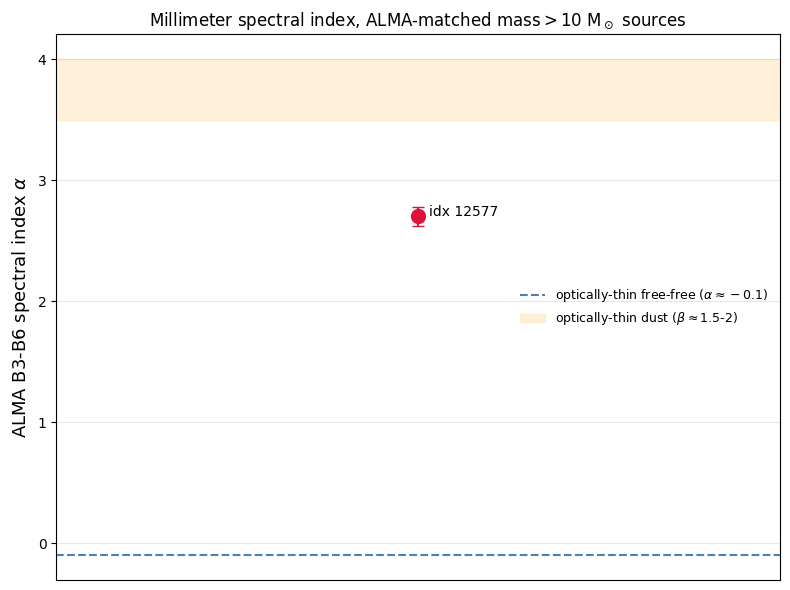

In [14]:

has_alpha = np.isfinite(alpha_tab['alpha'])
fig, ax = plt.subplots(figsize=(8, 6))
if has_alpha.sum() > 0:
    ax.errorbar(np.arange(has_alpha.sum()), alpha_tab['alpha'][has_alpha], yerr=alpha_tab['alphaerr'][has_alpha],
                fmt='o', markersize=10, capsize=4, color='crimson')
    for k, row in enumerate(alpha_tab[has_alpha]):
        ax.annotate(f"idx {row['idx']}", (k, row['alpha']), textcoords='offset points', xytext=(8, 0), fontsize=10)
ax.axhline(-0.1, color='steelblue', ls='--', label=r'optically-thin free-free ($\alpha\approx-0.1$)')
ax.axhspan(3.5, 4.0, color='orange', alpha=0.15, label=r'optically-thin dust ($\beta\approx1.5$-$2$)')
ax.set_xlim(-1, max(has_alpha.sum(), 1))
ax.set_xticks([])
ax.set_ylabel(r'ALMA B3-B6 spectral index $\alpha$')
ax.set_title('Millimeter spectral index, ALMA-matched mass$>$10 M$_\\odot$ sources')
ax.legend(fontsize=9, frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step5_alma_spectral_index.png', dpi=120, bbox_inches='tight')
plt.show()



**Result:** only one of the five ALMA-matched (<0.5") sources has a detection in both ALMA
bands at this position (the rest are single-band B3-only or B6-only detections, so no
spectral index is computable from this catalog for them) - idx 12577, with
$\alpha=2.70\pm0.08$. This sits below the optically-thin-dust range ($\alpha\sim3.5$-$4$)
but well above the optically-thin free-free value ($\alpha\approx-0.1$), consistent with
either partially optically-thick dust emission or a mix of dust and a subdominant
ionized-gas contribution - it does not by itself confirm an HII region, but it is not a
simple optically-thin-dust-only spectrum either. Note idx 12577's ALMA counterpart is 0.28"
away (roughly 1-2 beam widths), looser than the other matches, so some caution on the
positional association is warranted. The single-band-only limitation for the other four
sources means this particular test is not yet very constraining for most of the sample;
multi-frequency (radio, not just B3/B6) continuum data would help more, as demonstrated by
the d7/idx 4685 VLA spectral index test earlier in this analysis.



## Cutouts of the ALMA/VLA-matched sources: diffuse emission and other features

We inspect multi-band postage stamps (F162M, F210M, F360M, F480M, F560W, F770W) around
each of the six sources with an ALMA or VLA match within 0.5" (idx 12575, 10956, 12577,
10948, 4685, 12120), looking for diffuse nebulosity, multiplicity, or other structure that
the point-source photometry alone would miss.


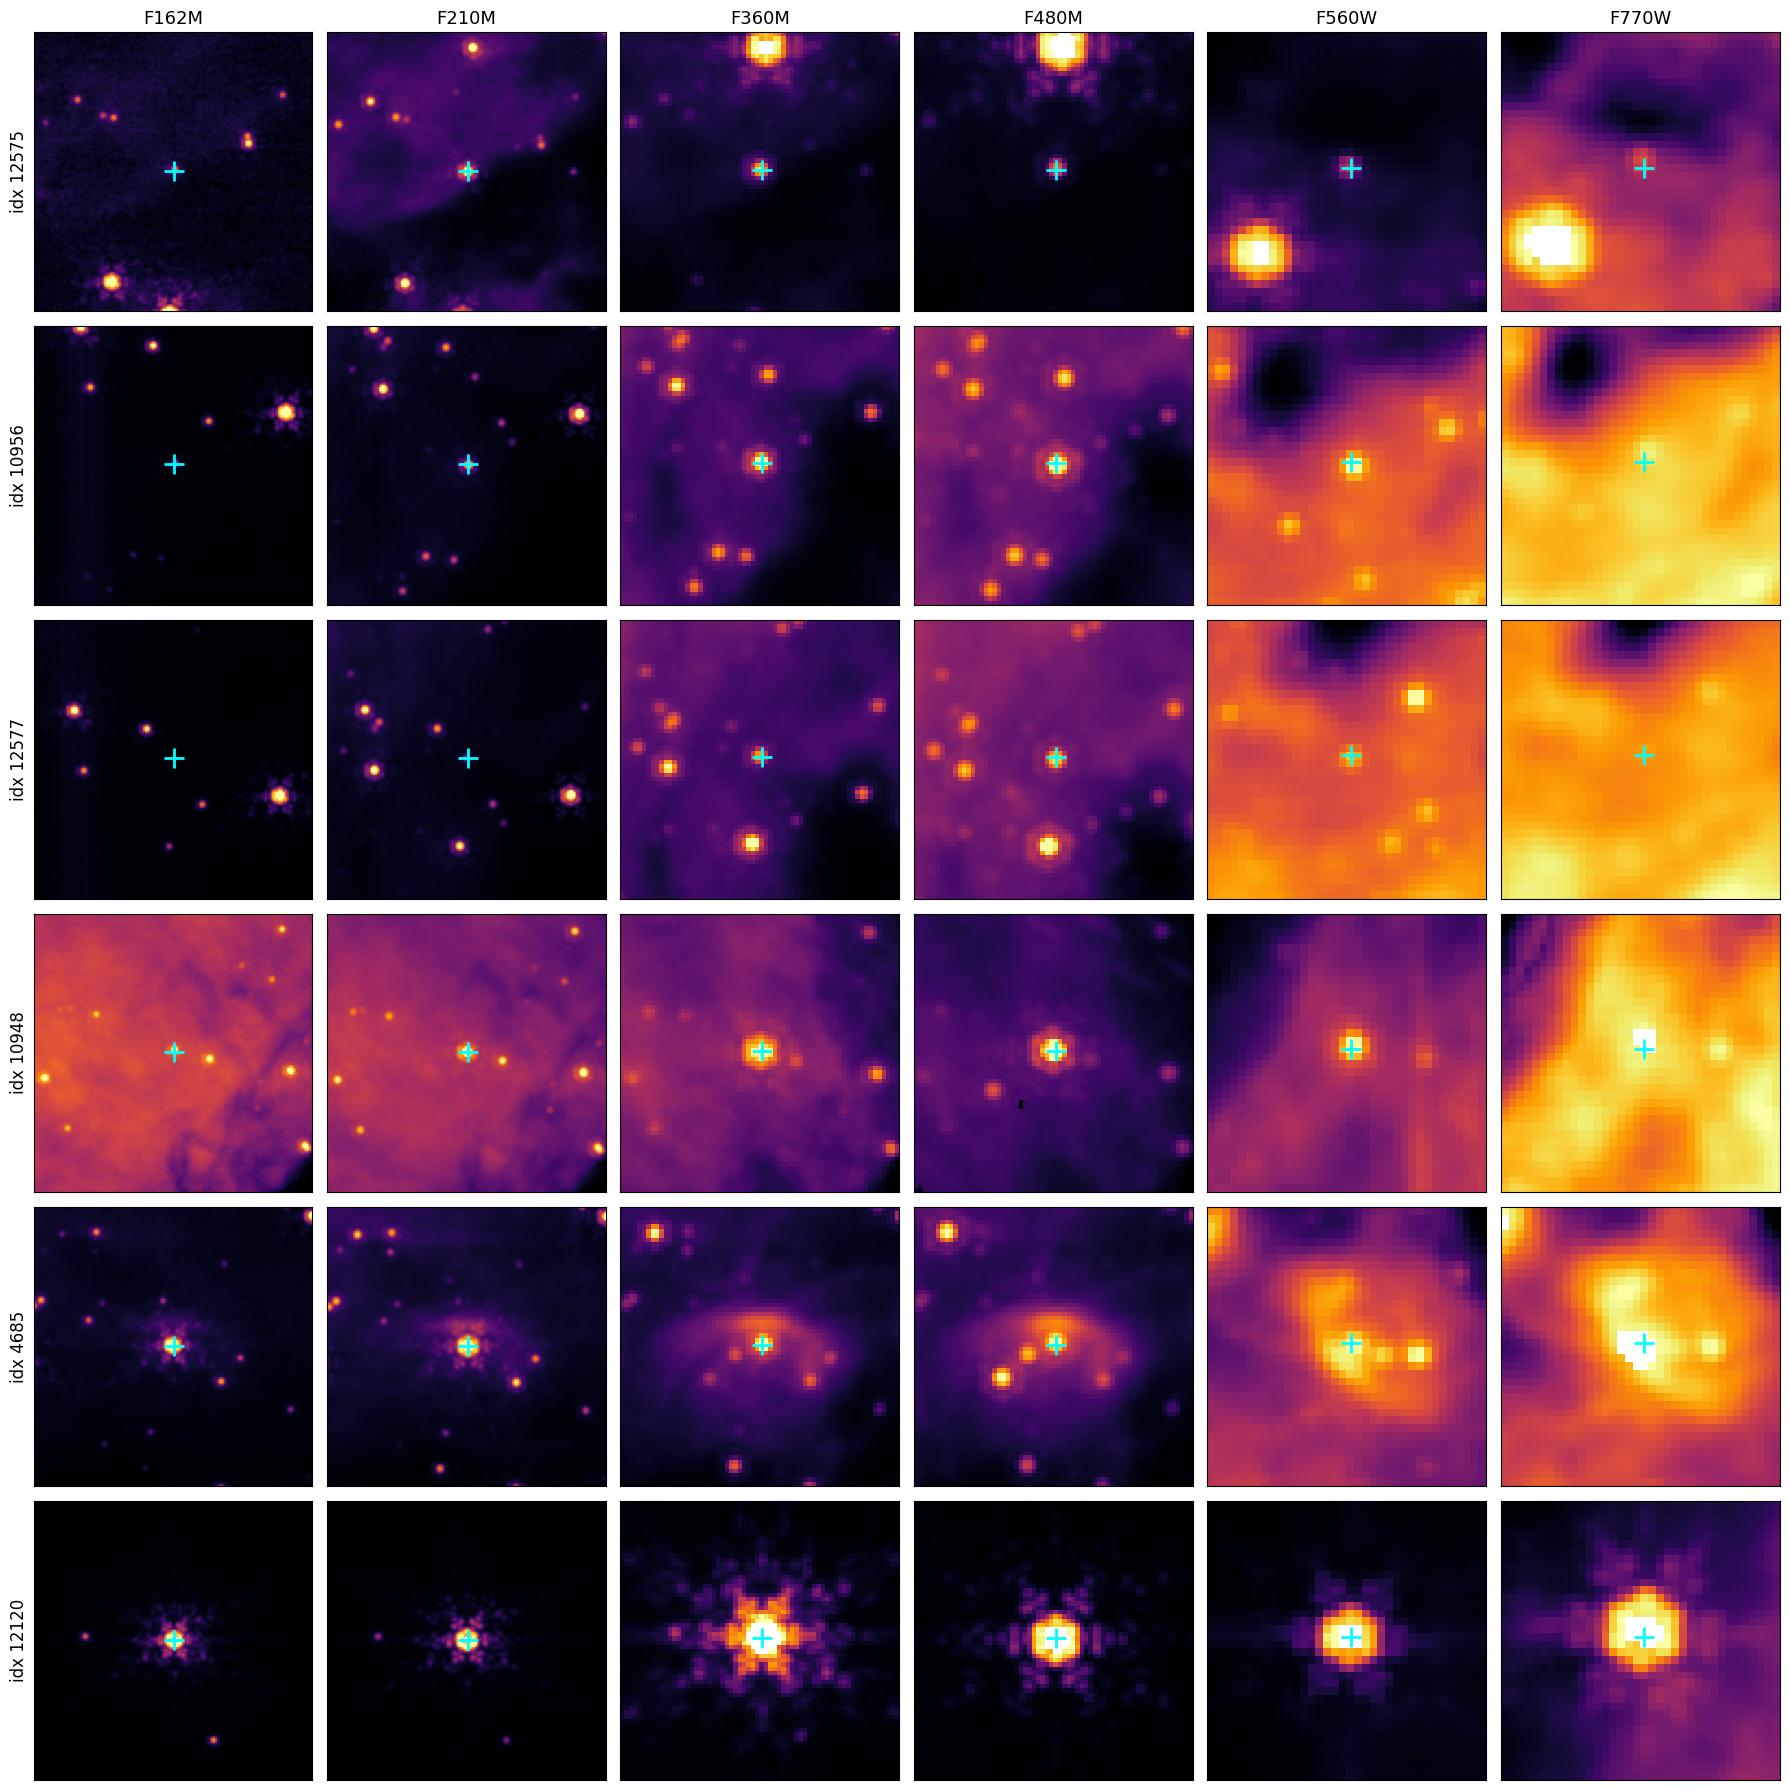

In [15]:

cutout_targets = [12575, 10956, 12577, 10948, 4685, 12120]
box_arcsec = 2.0
cutout_bands = ['f162m', 'f210m', 'f360m', 'f480m', 'f560w', 'f770w']
cutout_wcses = {b: WCS(headers[b]) for b in cutout_bands}
cutout_data = {b: fits.getdata(image_filenames[b], ext=('SCI', 1)) for b in cutout_bands}
cutout_pixscale = {b: cutout_wcses[b].proj_plane_pixel_scales()[0].to(u.arcsec).value for b in cutout_bands}

from astropy.visualization import simple_norm

fig, axes = plt.subplots(len(cutout_targets), len(cutout_bands), figsize=(3*len(cutout_bands), 3*len(cutout_targets)))
for row, i in enumerate(cutout_targets):
    ra, dec = ra_all[i], dec_all[i]
    for col, b in enumerate(cutout_bands):
        axi = axes[row, col]
        x, y = cutout_wcses[b].all_world2pix(ra, dec, 0)
        x, y = int(round(float(x))), int(round(float(y)))
        box = int(round(box_arcsec / cutout_pixscale[b]))
        y0, y1 = max(0, y-box), y+box
        x0, x1 = max(0, x-box), x+box
        cut = cutout_data[b][y0:y1, x0:x1]
        if cut.size == 0 or np.all(~np.isfinite(cut)):
            axi.text(0.5, 0.5, 'no data', ha='center', va='center', transform=axi.transAxes)
        else:
            try:
                norm = simple_norm(cut, stretch='asinh', percent=99.7)
                axi.imshow(cut, origin='lower', cmap='inferno', norm=norm)
            except Exception:
                axi.imshow(cut, origin='lower', cmap='inferno')
            cy, cx = cut.shape[0]//2, cut.shape[1]//2
            axi.plot(cx, cy, '+', color='cyan', markersize=14, markeredgewidth=2)
        axi.set_xticks([]); axi.set_yticks([])
        if row == 0:
            axi.set_title(b.upper(), fontsize=13)
        if col == 0:
            axi.set_ylabel(f'idx {i}', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step6_cutouts_alma_vla_matched.png', dpi=110, bbox_inches='tight')
plt.show()



**What stands out:**

- **idx 4685** shows clear **multiplicity**: 2-3 resolved point sources within a couple of
  beam widths of each other at F360M-F770W, sitting inside an **arc-shaped diffuse
  structure** that looks like a cavity or shell wall, not a simple symmetric envelope. This
  is consistent with a small multiple protostellar system and/or an outflow cavity, and is
  the most visually complex source of the six.
- **idx 10948** shows **diffuse nebulosity visible already at F162M/F210M** (near-IR), unlike
  the other five where the near-IR frames are essentially clean starfields. At F560W there
  is a sharp, roughly linear brightness discontinuity crossing the frame, suggestive of an
  illuminated cavity/PDR wall rather than a smooth envelope. This is also our tightest ALMA
  positional match (0.040") among the six.
- **idx 10956 and idx 12577** both sit in front of very bright, extended, partially
  saturated diffuse emission at F560W/F770W that floods the larger MIRI point-spread
  function - consistent with both being embedded in (or projected against) the luminous
  W51e2 hot-core/HII-region complex rather than being isolated objects. This large-scale
  luminous environment is itself hard to reconcile with an unrelated foreground AGB star.
- **idx 12120** is the cleanest, most isolated point source of the six - strong diffraction
  spikes at every band, no visible companions or diffuse structure. Different character
  from the other five: a single, compact, very extincted object rather than one embedded in
  obvious extended structure.
- **idx 12575** is a caution flag: it has **no visually obvious point source at F162M or
  F210M** at the cataloged position (just faint background/diffuse cloud structure), and at
  F560W/F770W the frame is dominated by an unrelated bright, saturated star to the
  lower-left. Its only clean detections are at F360M/F480M. Combined with its large
  isochrone-mass extrapolation and its being the tightest positional Pa$\alpha$+ALMA match
  in the sample, this source deserves a dedicated re-check of its photometry before being
  treated as a confirmed massive protostar.


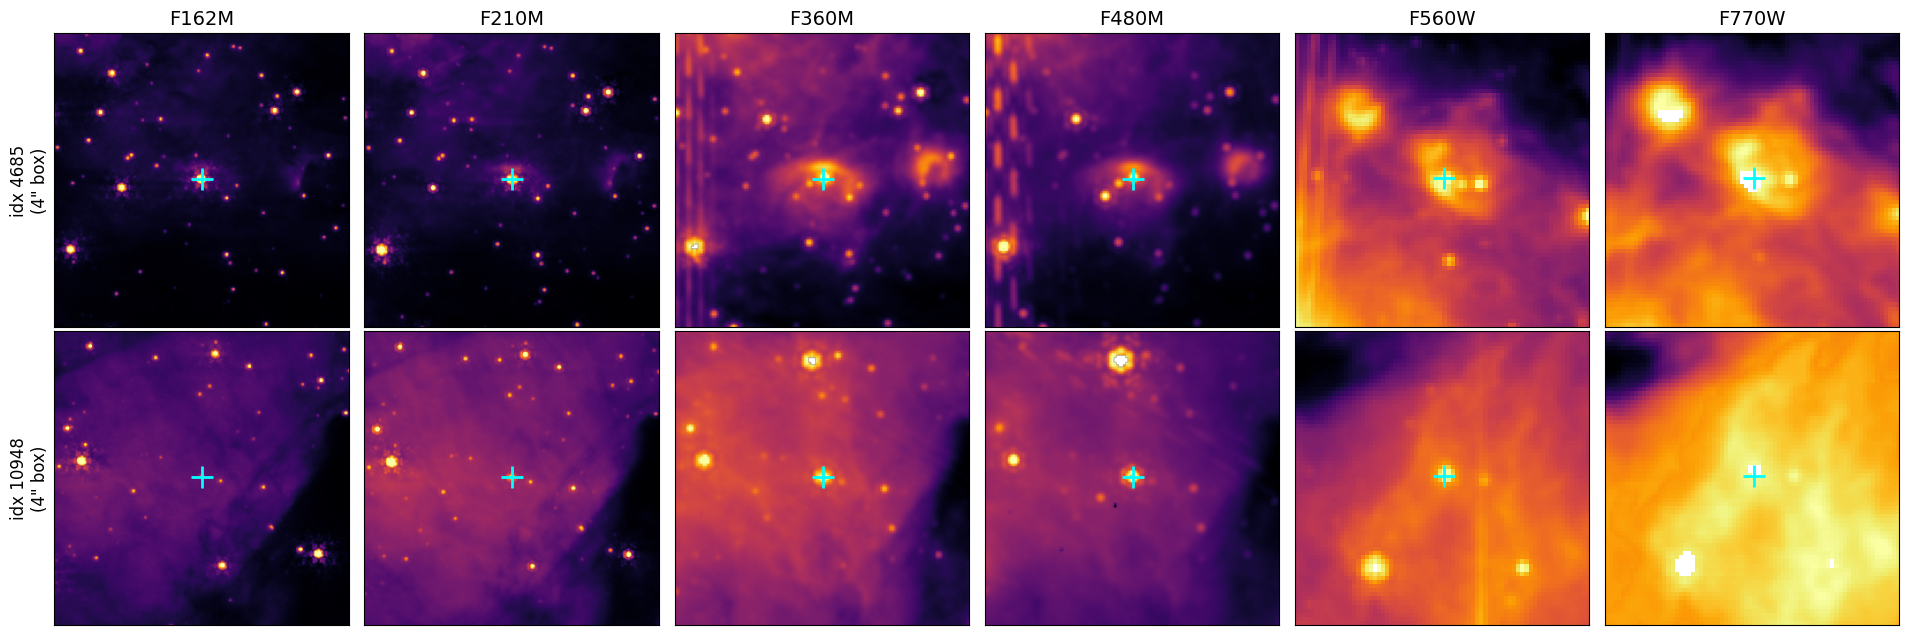

In [16]:

zoom_targets = [4685, 10948]
box_arcsec_zoom = 4.0
fig, axes = plt.subplots(len(zoom_targets), len(cutout_bands), figsize=(3.2*len(cutout_bands), 3.2*len(zoom_targets)))
for row, i in enumerate(zoom_targets):
    ra, dec = ra_all[i], dec_all[i]
    for col, b in enumerate(cutout_bands):
        axi = axes[row, col]
        x, y = cutout_wcses[b].all_world2pix(ra, dec, 0)
        x, y = int(round(float(x))), int(round(float(y)))
        box = int(round(box_arcsec_zoom / cutout_pixscale[b]))
        y0, y1 = max(0, y-box), y+box
        x0, x1 = max(0, x-box), x+box
        cut = cutout_data[b][y0:y1, x0:x1]
        if cut.size == 0 or np.all(~np.isfinite(cut)):
            axi.text(0.5, 0.5, 'no data', ha='center', va='center', transform=axi.transAxes)
        else:
            norm = simple_norm(cut, stretch='asinh', percent=99.7)
            axi.imshow(cut, origin='lower', cmap='inferno', norm=norm)
            cy, cx = cut.shape[0]//2, cut.shape[1]//2
            axi.plot(cx, cy, '+', color='cyan', markersize=16, markeredgewidth=2)
        axi.set_xticks([]); axi.set_yticks([])
        if row == 0:
            axi.set_title(b.upper(), fontsize=14)
        if col == 0:
            axi.set_ylabel(f'idx {i}\n(4" box)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step6b_zoom_interesting.png', dpi=120, bbox_inches='tight')
plt.show()



**Zoomed view (4" box) of the two most morphologically interesting sources.** idx 4685's
multiplicity and cavity/arc structure and idx 10948's near-IR-visible diffuse nebulosity and
sharp brightness edge are both clearer at this larger scale. Both would be good targets for
a closer look at the underlying ALMA/VLA image cutouts (not just the JWST postage stamps
shown here) if pursuing the multiplicity or cavity-wall interpretation further.



## Robitaille SED fitting with a corrected $A_V$ constraint: is stellar T/L consistent across geometry?

**Correction from the previous version of this section:** using the isochrone $A_V$ as a
*lower limit* was wrong. That $A_V$ is estimated from the near-IR color alone, which
reddens due to **all** dust along the line of sight - interstellar *and* any circumstellar
dust already contributing to the observed photosphere-like colors. The `sedfitter`
package's own `av` parameter, by contrast, represents *only* an additional foreground
screen applied on top of whatever the chosen geometry's radiative transfer already
produces - the geometry's own disk/envelope reprocessing is handled separately. Using our
isochrone $A_V$ as a *lower limit* therefore double-counts: it can force the fitter to
add foreground reddening on top of dust the geometry already modeled internally. The
correct role for this $A_V$ is an **upper limit** (ceiling) on the foreground-only
parameter: `av_range=[0, av_isochrone]`.

**What this can and cannot do:** with $A_V$ properly bounded above rather than below, nothing
forces a particular answer - if a cool, unreddened solution genuinely fits best within
that ceiling, the fitter is free to find it. So the interesting question is not "which
geometry wins" (already shown to be statistically meaningless here - with a median of
only 10 photometric bands per source, the 12-parameter envelope geometry has zero or
negative degrees of freedom for 90%+ of the sample, so neither raw $\chi^2$ nor AIC-style
corrections are reliable model-selection tools at this data budget). The useful question
is: **does the fitter converge on a *consistent* stellar temperature and luminosity
regardless of which circumstellar geometry is assumed?** If yes, that consistency is
itself meaningful, geometry-independent evidence about the star. If no, it demonstrates
directly that the data cannot pin down stellar parameters at all without first knowing the
circumstellar structure - a genuine, honest limitation to report rather than paper over.

We re-fit the mass$>15\ M_\odot$ sample (Step 1b's revised, safety-margin cut) against the
same three geometries as before (bare star / star+disk / star+disk+envelope+cavity), now
with $A_V$ correctly bounded as $[0,\ A_{V,\mathrm{isochrone}}]$, and compare the resulting
star.temperature and luminosity **across geometries, per source**.


In [17]:

from astropy.table import Table as _T
fit_tab = _T.read('/tmp/claude-21299/-blue-adamginsburg-t-yoo-w51-nircam/d4821ccc-1be1-4e69-b46d-1550a2aa86a8/scratchpad/ceiling_av_sed_fits.csv')
fit_tab.write('massive_ob_candidates_ceiling_av_sed_fits.csv', format='csv', overwrite=True)

geoms = ['s---s-i', 'sp--s-i', 'spubhmi']
n_params = {'s---s-i': 3, 'sp--s-i': 6, 'spubhmi': 12}
labels = {'s---s-i': 'bare star', 'sp--s-i': 'star+disk', 'spubhmi': 'star+disk+envelope+cavity'}

idxs = np.unique(fit_tab['idx'])
rows = []
for i in idxs:
    sub = {r['geometry']: r for r in fit_tab[fit_tab['idx'] == i]}
    if not all(g in sub for g in geoms):
        continue
    Ts = np.array([sub[g]['star_temperature'] for g in geoms])
    Ls = np.array([sub[g]['model_luminosity'] for g in geoms])
    rows.append(dict(idx=int(i),
                      T_star=sub['s---s-i']['star_temperature'], T_disk=sub['sp--s-i']['star_temperature'],
                      T_env=sub['spubhmi']['star_temperature'],
                      L_star=sub['s---s-i']['model_luminosity'], L_disk=sub['sp--s-i']['model_luminosity'],
                      L_env=sub['spubhmi']['model_luminosity'],
                      T_ratio_max_min=Ts.max()/Ts.min(), L_ratio_max_min=Ls.max()/Ls.min(),
                      av_ceiling=sub['s---s-i']['av_ceiling']))
cons_tab = Table(rows=rows, names=rows[0].keys())
cons_tab.write('massive_ob_candidates_sed_consistency.csv', format='csv', overwrite=True)

print(f'{len(cons_tab)} sources fit against all 3 geometries with a shared Av ceiling\\n')
print(f'median T (bare star / +disk / +envelope): {np.median(cons_tab["T_star"]):.0f} / '
      f'{np.median(cons_tab["T_disk"]):.0f} / {np.median(cons_tab["T_env"]):.0f} K')
print(f'median T_max/T_min ratio across the 3 geometries: {np.median(cons_tab["T_ratio_max_min"]):.2f}')
print(f'median L_max/L_min ratio across the 3 geometries: {np.median(cons_tab["L_ratio_max_min"]):.2f}')
print()
consistent_T = (cons_tab['T_ratio_max_min'] < 1.5).sum()
consistent_L = (cons_tab['L_ratio_max_min'] < 3).sum()
print(f'N sources with T consistent within 1.5x across all 3 geometries: {consistent_T}/{len(cons_tab)}')
print(f'N sources with L consistent within 3x across all 3 geometries: {consistent_L}/{len(cons_tab)}')
print()
n_all_hot = ((cons_tab['T_star']>10000)&(cons_tab['T_disk']>10000)&(cons_tab['T_env']>10000)).sum()
print(f'N sources where ALL 3 geometries agree T>10,000K (unambiguously hot regardless of geometry): {n_all_hot}/{len(cons_tab)}')


46 sources fit against all 3 geometries with a shared Av ceiling\n
median T (bare star / +disk / +envelope): 2794 / 6942 / 4902 K
median T_max/T_min ratio across the 3 geometries: 2.90
median L_max/L_min ratio across the 3 geometries: 5.70

N sources with T consistent within 1.5x across all 3 geometries: 7/46
N sources with L consistent within 3x across all 3 geometries: 12/46

N sources where ALL 3 geometries agree T>10,000K (unambiguously hot regardless of geometry): 0/46


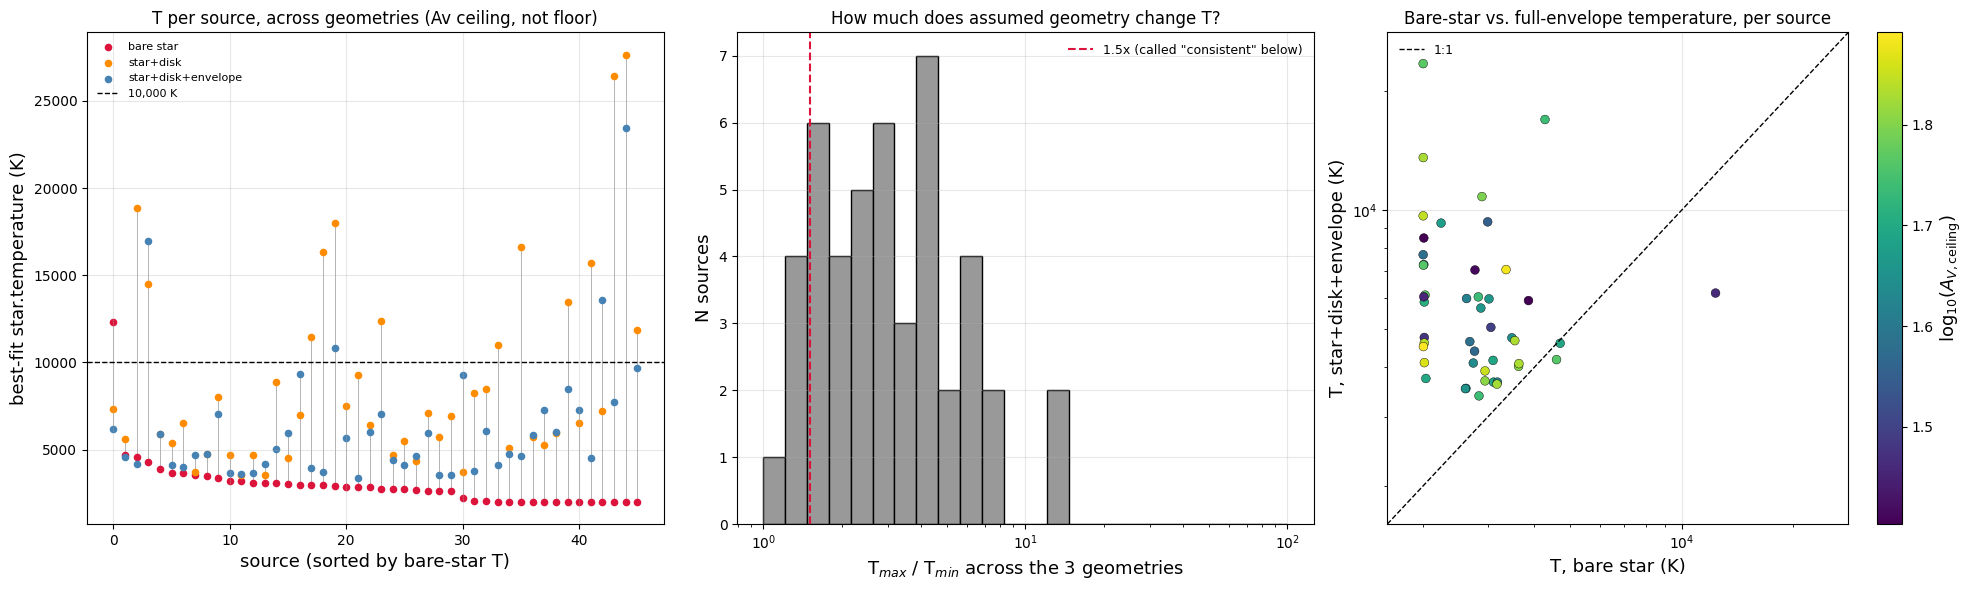

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
order = np.argsort(-cons_tab['T_star'])
xpos = np.arange(len(cons_tab))
ax.scatter(xpos, cons_tab['T_star'][order], s=20, c='crimson', label='bare star')
ax.scatter(xpos, cons_tab['T_disk'][order], s=20, c='darkorange', label='star+disk')
ax.scatter(xpos, cons_tab['T_env'][order], s=20, c='steelblue', label='star+disk+envelope')
for k in xpos:
    Ts = [cons_tab['T_star'][order][k], cons_tab['T_disk'][order][k], cons_tab['T_env'][order][k]]
    ax.plot([k, k], [min(Ts), max(Ts)], color='0.7', lw=0.7, zorder=0)
ax.axhline(10000, color='k', ls='--', lw=1, label='10,000 K')
ax.set_xlabel('source (sorted by bare-star T)'); ax.set_ylabel('best-fit star.temperature (K)')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)
ax.set_title('T per source, across geometries (Av ceiling, not floor)')

ax = axes[1]
ax.hist(cons_tab['T_ratio_max_min'], bins=np.logspace(0, 2, 25), color='0.6', edgecolor='k')
ax.axvline(1.5, color='crimson', ls='--', label='1.5x (called "consistent" below)')
ax.set_xscale('log')
ax.set_xlabel('T$_{max}$ / T$_{min}$ across the 3 geometries'); ax.set_ylabel('N sources')
ax.legend(fontsize=9, frameon=False); ax.grid(alpha=0.3)
ax.set_title('How much does assumed geometry change T?')

ax = axes[2]
sc = ax.scatter(cons_tab['T_star'], cons_tab['T_env'], c=np.log10(cons_tab['av_ceiling']), cmap='viridis', s=40, edgecolor='k', linewidth=0.3)
lims = [cons_tab['T_star'].min()*0.8, max(cons_tab['T_star'].max(), cons_tab['T_env'].max())*1.2]
ax.plot(lims, lims, 'k--', lw=1, label='1:1')
cbar = plt.colorbar(sc, ax=ax); cbar.set_label(r'log$_{10}(A_{V,\mathrm{ceiling}})$')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('T, bare star (K)'); ax.set_ylabel('T, star+disk+envelope (K)')
ax.legend(fontsize=9, frameon=False); ax.grid(alpha=0.3)
ax.set_title('Bare-star vs. full-envelope temperature, per source')

plt.tight_layout()
plt.savefig(f'{FIGDIR}/massiveob_step7_sed_geometry_consistency.png', dpi=120, bbox_inches='tight')
plt.show()



**Result: stellar temperature is not consistent across assumed geometry, and treating
$A_V$ correctly (as a ceiling) does not rescue the constraint** - if anything it makes the
degeneracy more visible:

- Median best-fit temperature is **2,794 K for a bare star, 6,942 K with a disk, and
  4,902 K with a full envelope** - not even a monotonic trend with geometry complexity,
  and none of these medians are hot.
- **Zero of the 46 sources have all three geometries agreeing on $T>10{,}000$ K** at once.
  Only 1/46 bare-star fits exceed 10,000 K on their own.
- The median $T_{max}/T_{min}$ ratio across the three geometries is **2.9x**; only 7/46
  (15%) sources land within a factor of 1.5 of each other across geometries. Luminosity is
  even less consistent (median ratio 5.7x, only 12/46 within a factor of 3).

The reason is straightforward once you see it: an upper-limit-only $A_V$ constraint mostly
does not bind, because the fitter already prefers *less* extinction whenever it can get
away with it - a cool, oversized "pseudo-photosphere" can mimic the reddened near/mid-IR
continuum shape just as well as a genuinely hot, compact, correctly-reddened star, and
without a floor there is nothing to rule that degenerate solution out. This is the same
degeneracy identified in the very first pass through this analysis; a correctly-specified
ceiling does not remove it, because the ceiling is rarely the thing stopping the fitter
from choosing a cool solution.

**This directly answers the original question:** no, constraining stellar parameters does
not give a consistent answer across assumed circumstellar geometry for this sample, at
this photometric-band budget. Combined with the earlier confirmation that raw
$\chi^2$/AIC-based geometry selection is not meaningful here either (median 10 bands vs. up
to 12 model parameters), the conclusion is that **SED fitting alone cannot deliver a
reliable stellar temperature or luminosity for most of this sample, regardless of how
$A_V$ is bounded.** The evidence that does not depend on any assumed geometry - the
bias-corrected Pa$\alpha$ excess (Step 2) and the model-independent color-color
"unreachable region" test (Step 3) - remains the trustworthy way to argue for hot,
ionizing, dust-excess sources here; SED-fit temperatures and luminosities should be read
as illustrative only, not as physical measurements.
